# ESRS Reporting Coverage Analytics
> **This file is preset to: `Mapping_ALLStacked_TU` — 5 companies + Thai Union (Nomad 2025, Espersen 2025)**
### Master's Thesis — Multi-Company

**Data source:** a stacked mapping sheet (set `STACKED_SHEET` in the config cell) + `ESRS_MASTER` universe.

**Scenarios available in `ESRS_KPI_Mapping_V5.xlsx`:**
- `Mapping_ALLStacked` — original 5 companies (Nomad 2024)
- `Mapping_ALLStacked_TU` — **5 companies + Thai Union** (Nomad 2024)
- `Mapping_ALLStacked_TU_N25` — **5 companies + Thai Union, Nomad, Espersen= 2025**

**v5 changes:** company set and palette are now dynamic (`n_companies = len(COMPANIES)`);
all "==5" / "all 5 companies" assumptions adapt automatically; choose the scenario
by editing `STACKED_SHEET` in the config cell.



## Cell 1 — Install and import

In [1]:
!pip install openpyxl matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from google.colab import files
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'figure.dpi': 130,
})

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Which stacked sheet to analyse. Set this to the variant you want:
#   'Mapping_ALLStacked'          -> original 5 companies (Nomad 2024)
#   'Mapping_ALLStacked_TU'       -> 5 companies + Thai Union (Nomad 2024)
#   'Mapping_ALLStacked_TU_N25'   -> 5 companies + Thai Union, Nomad = 2025
STACKED_SHEET = 'Mapping_ALLStacked_TU_N25'   # <-- EDIT THIS LINE to switch scenario

# Base palette; any company not listed gets an auto colour.
BASE_COLORS = {
    'Bolton':'#2E5F8A', 'Espersen':'#1A5C3A', 'Mowi':'#7B3F00',
    'Nomad':'#5B2C6F', 'Profand':'#1A6B8A', 'Thai Union':'#B03A2E',
}
_EXTRA = ['#117A65','#6C3483','#B9770E','#1F618D','#922B21','#196F3D']
def build_company_colors(companies):
    cmap = {}
    j = 0
    for c in companies:
        if c in BASE_COLORS:
            cmap[c] = BASE_COLORS[c]
        else:
            cmap[c] = _EXTRA[j % len(_EXTRA)]; j += 1
    return cmap

print('Ready. STACKED_SHEET =', STACKED_SHEET)


Ready. STACKED_SHEET = Mapping_ALLStacked_TU_N25


## Cell 2 — Upload your Excel file

In [4]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'✅ Uploaded: {filename}')

Saving ESRS_KPI_Mapping_V7.xlsx to ESRS_KPI_Mapping_V7.xlsx
✅ Uploaded: ESRS_KPI_Mapping_V7.xlsx


## Cell 3 — Load and clean data

In [5]:
# ── Load stacked mapping sheet (variant chosen in CONFIG) ─────────────────────
raw = pd.read_excel(filename, sheet_name=STACKED_SHEET)

for col in ['Company','Topic','DR']:
    raw[col] = raw[col].astype(str).str.strip()

df = raw.dropna(subset=['DR']).copy()
df = df[df['DR'].str.strip() != ''].copy()

import re
df = df[df['DR'].str.match(r'^[ESG]\d-\d')].copy()

print(f'Sheet: {STACKED_SHEET}')
print(f'Rows after cleaning: {len(df)}')
print(f'Companies: {sorted(df["Company"].unique())}')
print()

# ── Load ESRS_MASTER as full universe ─────────────────────────────────────────
master_raw = pd.read_excel(filename, sheet_name='ESRS_MASTER', header=2)
master = master_raw[master_raw['ESRS_ID'].notna()].copy()
master['DR']    = master['DR'].astype(str).str.strip()
master['Topic'] = master['Topic'].astype(str).str.strip()

all_drs = sorted(master[master['DR'].str.match(r'^[ESG]\d-\d', na=False)]['DR'].unique())
print(f'ESRS_MASTER universe: {len(all_drs)} unique DRs')
print()

# Companies + dynamic palette + count (replaces the hard-coded 5)
COMPANIES = sorted(df['Company'].unique())
COMPANY_COLORS = build_company_colors(COMPANIES)
n_companies = len(COMPANIES)
print(f'n_companies = {n_companies}')
print('Rows per company:')
print(df['Company'].value_counts().to_string())


Sheet: Mapping_ALLStacked_TU_N25
Rows after cleaning: 441
Companies: ['Bolton', 'Espersen 2025', 'Mowi', 'Nomad 2025', 'Profand 2025', 'Thai Union']

ESRS_MASTER universe: 70 unique DRs

n_companies = 6
Rows per company:
Company
Thai Union       158
Nomad 2025        96
Profand 2025      68
Bolton            46
Mowi              39
Espersen 2025     34


In [6]:
# ── Inspect ESRS_MASTER universe: how many unique DRs? ────────────────────────
print(f'Total unique DRs in ESRS_MASTER universe: {len(all_drs)}')
print()

# Breakdown by standard
from collections import Counter
std_counts = Counter(dr[:2] for dr in all_drs)

print('DRs per standard:')
for std in sorted(std_counts):
    drs_in_std = [dr for dr in all_drs if dr[:2] == std]
    print(f'  {std}: {std_counts[std]:>2}  ({", ".join(drs_in_std)})')

print()
print(f'Standards covered: {len(std_counts)}  ({", ".join(sorted(std_counts))})')

Total unique DRs in ESRS_MASTER universe: 70

DRs per standard:
  E1:  9  (E1-1, E1-2, E1-3, E1-4, E1-5, E1-6, E1-7, E1-8, E1-9)
  E2:  6  (E2-1, E2-2, E2-3, E2-4, E2-5, E2-6)
  E3:  5  (E3-1, E3-2, E3-3, E3-4, E3-5)
  E4:  6  (E4-1, E4-2, E4-3, E4-4, E4-5, E4-6)
  E5:  6  (E5-1, E5-2, E5-3, E5-4, E5-5, E5-6)
  G1:  6  (G1-1, G1-2, G1-3, G1-4, G1-5, G1-6)
  S1: 17  (S1-1, S1-10, S1-11, S1-12, S1-13, S1-14, S1-15, S1-16, S1-17, S1-2, S1-3, S1-4, S1-5, S1-6, S1-7, S1-8, S1-9)
  S2:  5  (S2-1, S2-2, S2-3, S2-4, S2-5)
  S3:  5  (S3-1, S3-2, S3-3, S3-4, S3-5)
  S4:  5  (S4-1, S4-2, S4-3, S4-4, S4-5)

Standards covered: 10  (E1, E2, E3, E4, E5, G1, S1, S2, S3, S4)


## Cell 4 — Build coverage matrix

A binary matrix: rows = all ESRS DRs, columns = companies.  
`1` = company reports this DR, `0` = does not.

In [7]:
# Build binary coverage matrix (DR × Company)
coverage = pd.DataFrame(0, index=all_drs, columns=COMPANIES)

for _, row in df.iterrows():
    if row['DR'] in coverage.index:
        coverage.loc[row['DR'], row['Company']] = 1

coverage.index.name = 'DR'

# Add helper columns
coverage['N_Companies_Reporting'] = coverage[COMPANIES].sum(axis=1)
coverage['Topic'] = coverage.index.str[:2]

print(f'Coverage matrix: {len(coverage)} DRs × {len(COMPANIES)} companies')
print()
print('Coverage matrix (first 15 rows):')
display(coverage.head(15))

Coverage matrix: 70 DRs × 6 companies

Coverage matrix (first 15 rows):


,Bolton,Espersen 2025,Mowi,Nomad 2025,Profand 2025,Thai Union,N_Companies_Reporting,Topic
DR,,,,,,,,
E1-1,1,0,1,0,0,0,2,E1
E1-2,1,1,0,1,0,1,4,E1
E1-3,1,1,1,1,0,1,5,E1
E1-4,1,1,1,1,1,1,6,E1
E1-5,1,1,1,1,1,1,6,E1
E1-6,1,1,1,1,1,1,6,E1
E1-7,0,0,0,1,0,1,2,E1
E1-8,0,0,0,0,0,0,0,E1
E1-9,0,0,0,0,0,1,1,E1


## Cell 5 — DR coverage rate per company

What % of the total ESRS universe does each company report?

=== DR Coverage Rate per Company ===


,Reported DRs,Total DRs in Universe,Coverage Rate (%)
Thai Union,53.0,70.0,75.7
Bolton,45.0,70.0,64.3
Nomad 2025,42.0,70.0,60.0
Profand 2025,38.0,70.0,54.3
Espersen 2025,34.0,70.0,48.6
Mowi,33.0,70.0,47.1


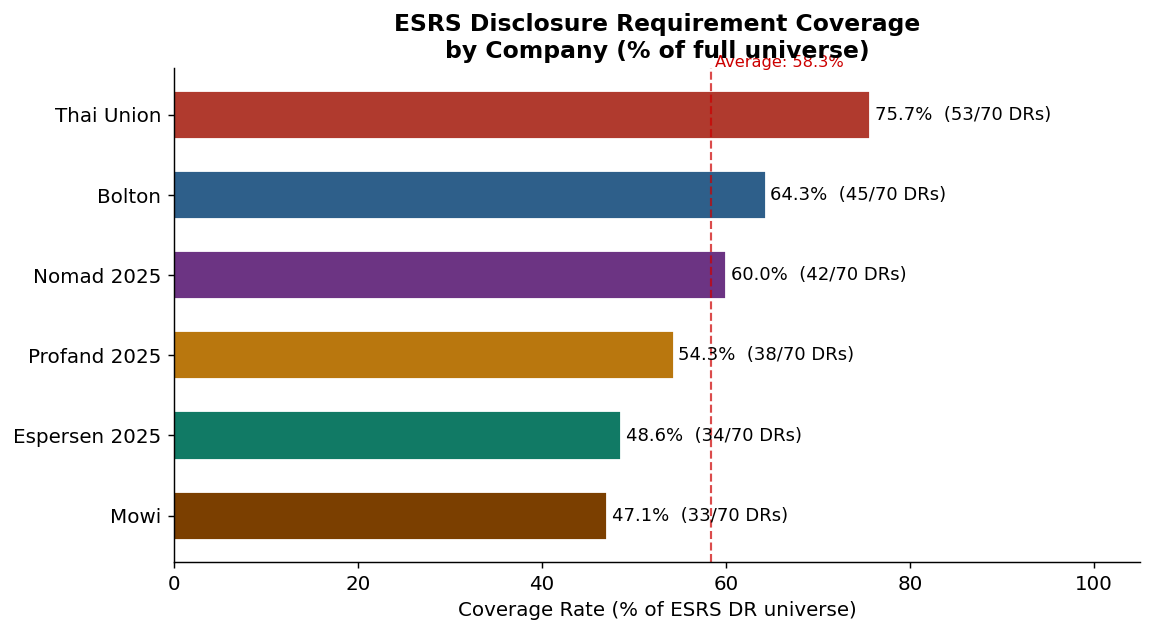

Chart saved.


In [8]:
total_drs = len(all_drs)

coverage_rates = {}
for company in COMPANIES:
    reported = coverage[company].sum()
    rate = reported / total_drs * 100
    coverage_rates[company] = {'Reported DRs': int(reported),
                                'Total DRs in Universe': total_drs,
                                'Coverage Rate (%)': round(rate, 1)}

coverage_df = pd.DataFrame(coverage_rates).T.sort_values('Coverage Rate (%)', ascending=False)
print('=== DR Coverage Rate per Company ===')
display(coverage_df)

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
companies_sorted = coverage_df.index.tolist()
rates = coverage_df['Coverage Rate (%)'].values
reported = coverage_df['Reported DRs'].values
colors = [COMPANY_COLORS.get(c, '#666666') for c in companies_sorted]

bars = ax.barh(companies_sorted, rates, color=colors, height=0.6, edgecolor='white')

# Add value labels
for bar, rate, rep in zip(bars, rates, reported):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{rate}%  ({int(rep)}/{total_drs} DRs)',
            va='center', fontsize=10)

ax.set_xlabel('Coverage Rate (% of ESRS DR universe)')
ax.set_title('ESRS Disclosure Requirement Coverage\nby Company (% of full universe)')
ax.set_xlim(0, 105)
ax.axvline(x=rates.mean(), color='#CC0000', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(rates.mean() + 0.5, -0.6, f'Average: {rates.mean():.1f}%', color='#CC0000', fontsize=9)
ax.invert_yaxis()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('chart_coverage_rate.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved.')

## Cell 6 — Coverage heatmap: Company × ESRS Standard

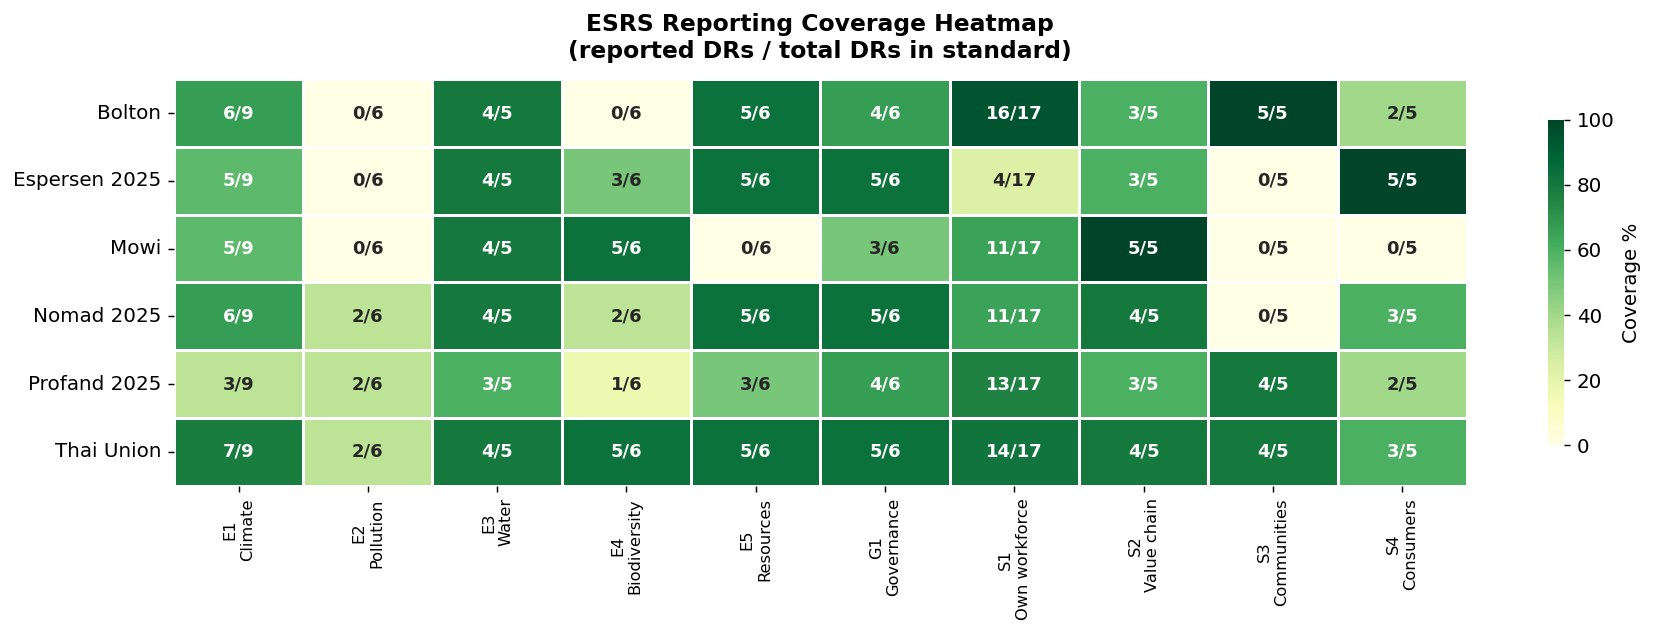


Heatmap data (% coverage per standard):


,E1,E2,E3,E4,E5,G1,S1,S2,S3,S4
Bolton,67.0,0.0,80.0,0.0,83.0,67.0,94.0,60.0,100.0,40.0
Espersen 2025,56.0,0.0,80.0,50.0,83.0,83.0,24.0,60.0,0.0,100.0
Mowi,56.0,0.0,80.0,83.0,0.0,50.0,65.0,100.0,0.0,0.0
Nomad 2025,67.0,33.0,80.0,33.0,83.0,83.0,65.0,80.0,0.0,60.0
Profand 2025,33.0,33.0,60.0,17.0,50.0,67.0,76.0,60.0,80.0,40.0
Thai Union,78.0,33.0,80.0,83.0,83.0,83.0,82.0,80.0,80.0,60.0


In [9]:
# Get all unique standards from the universe
all_standards = sorted(set(dr[:2] for dr in all_drs))

# For each company × standard: how many DRs reported vs total possible
heatmap_count  = pd.DataFrame(index=COMPANIES, columns=all_standards, dtype=float)
heatmap_pct    = pd.DataFrame(index=COMPANIES, columns=all_standards, dtype=float)
heatmap_labels = pd.DataFrame(index=COMPANIES, columns=all_standards, dtype=str)

for company in COMPANIES:
    for std in all_standards:
        # DRs in universe for this standard
        universe_drs = [dr for dr in all_drs if dr[:2] == std]
        # DRs reported by this company for this standard
        reported_drs = coverage.loc[universe_drs, company].sum()
        total_std    = len(universe_drs)
        pct = reported_drs / total_std * 100 if total_std > 0 else 0
        heatmap_count.loc[company, std] = reported_drs
        heatmap_pct.loc[company, std]   = round(pct, 0)
        heatmap_labels.loc[company, std] = f'{int(reported_drs)}/{total_std}'

heatmap_pct = heatmap_pct.astype(float)

# Standard labels with full names
STD_LABELS = {
    'E1':'E1\nClimate', 'E2':'E2\nPollution', 'E3':'E3\nWater',
    'E4':'E4\nBiodiversity', 'E5':'E5\nResources',
    'S1':'S1\nOwn workforce', 'S2':'S2\nValue chain',
    'S3':'S3\nCommunities', 'S4':'S4\nConsumers',
    'G1':'G1\nGovernance'
}
col_labels = [STD_LABELS.get(s, s) for s in all_standards]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_pct,
    ax=ax,
    annot=heatmap_labels.values,
    fmt='',
    cmap='YlGn',
    linewidths=0.8,
    linecolor='white',
    vmin=0, vmax=100,
    cbar_kws={'label': 'Coverage %', 'shrink': 0.8},
    xticklabels=col_labels,
    yticklabels=COMPANIES,
    annot_kws={'size': 10, 'weight': 'bold'}
)
ax.set_title('ESRS Reporting Coverage Heatmap\n(reported DRs / total DRs in standard)', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('chart_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print()
print('Heatmap data (% coverage per standard):')
display(heatmap_pct)

## Cell 7 — Gap analysis: how many companies report each DR?

=== DR Reporting Frequency Distribution ===
  No company           ->   8 DRs (11.4%)
  1 company only       ->   6 DRs (8.6%)
  2 companies          ->   6 DRs (8.6%)
  3 companies          ->  12 DRs (17.1%)
  4 companies          ->  12 DRs (17.1%)
  5 companies          ->  13 DRs (18.6%)
  All 6 companies      ->  13 DRs (18.6%)

DRs reported by ALL 6 companies (full consensus):
  ['E1-4', 'E1-5', 'E1-6', 'E3-2', 'E3-3', 'E3-4', 'G1-1', 'G1-3', 'S1-1', 'S1-14', 'S1-6', 'S2-1', 'S2-3']

DRs reported by NO company (complete gaps):
  ['E1-8', 'E2-1', 'E2-5', 'E2-6', 'E3-5', 'E4-6', 'E5-6', 'G1-6']


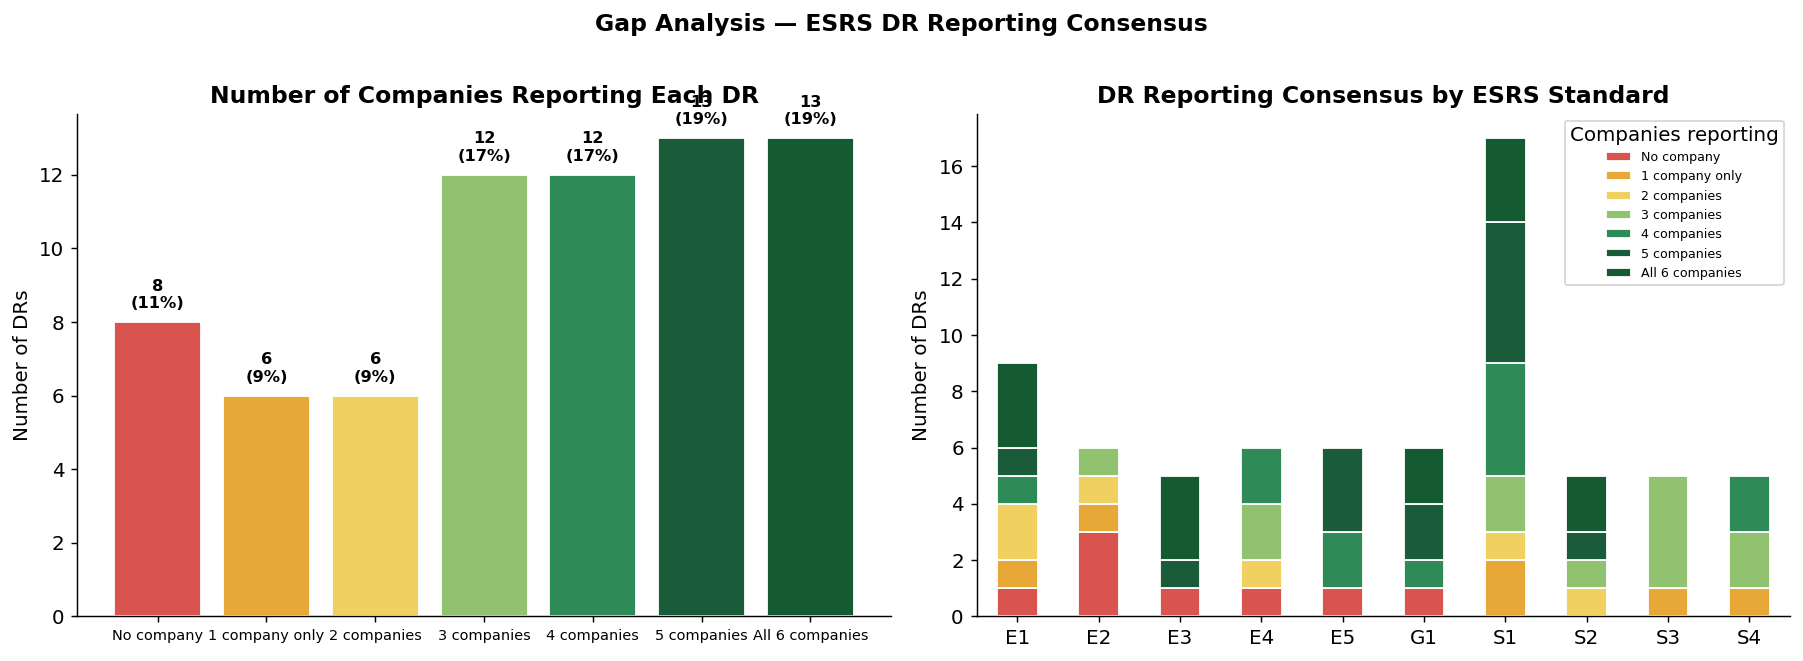

In [10]:
# Distribution of how many companies report each DR (dynamic in n_companies)
dist = coverage['N_Companies_Reporting'].value_counts().sort_index()

def freq_label(n):
    if n == 0: return 'No company'
    if n == 1: return '1 company only'
    if n == n_companies: return f'All {n_companies} companies'
    return f'{n} companies'

print('=== DR Reporting Frequency Distribution ===')
for n, count in dist.items():
    print(f'  {freq_label(n):20} -> {count:3d} DRs ({count/len(all_drs)*100:.1f}%)')

print()
print(f'DRs reported by ALL {n_companies} companies (full consensus):')
universal = coverage[coverage['N_Companies_Reporting'] == n_companies].index.tolist()
print(f'  {universal}')
print()
print('DRs reported by NO company (complete gaps):')
gaps = coverage[coverage['N_Companies_Reporting'] == 0].index.tolist()
print(f'  {gaps}')

# ── Chart: distribution (dynamic palette length) ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
base_palette = ['#D9534F','#E8A838','#F0D060','#90C270','#2E8B57','#1A5C3A',
                '#145A32','#0B5345','#073B3A','#052e2b']
palette = base_palette[:n_companies+1]
x_vals  = list(range(0, n_companies+1))
y_vals  = [dist.get(x, 0) for x in x_vals]
bars = ax1.bar([freq_label(x) for x in x_vals], y_vals, color=palette, edgecolor='white')
for bar, val in zip(bars, y_vals):
    if val > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val}\n({val/len(all_drs)*100:.0f}%)', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
ax1.set_title('Number of Companies Reporting Each DR')
ax1.set_ylabel('Number of DRs'); ax1.tick_params(axis='x', labelsize=8)
sns.despine(ax=ax1)

all_standards = sorted(set(dr[:2] for dr in all_drs))
std_consensus = pd.DataFrame(index=all_standards, columns=range(n_companies+1), data=0)
for std in all_standards:
    for dr in [d for d in all_drs if d[:2]==std]:
        n = int(coverage.loc[dr, 'N_Companies_Reporting'])
        std_consensus.loc[std, n] += 1
std_consensus.plot(kind='bar', stacked=True, ax=ax2, color=palette, edgecolor='white', legend=True)
ax2.set_title('DR Reporting Consensus by ESRS Standard')
ax2.set_ylabel('Number of DRs'); ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)
ax2.legend([freq_label(i) for i in range(n_companies+1)], loc='upper right', fontsize=7, title='Companies reporting')
sns.despine(ax=ax2)
plt.suptitle('Gap Analysis — ESRS DR Reporting Consensus', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()


## Cell 8 — Reporting depth per ESRS standard per company

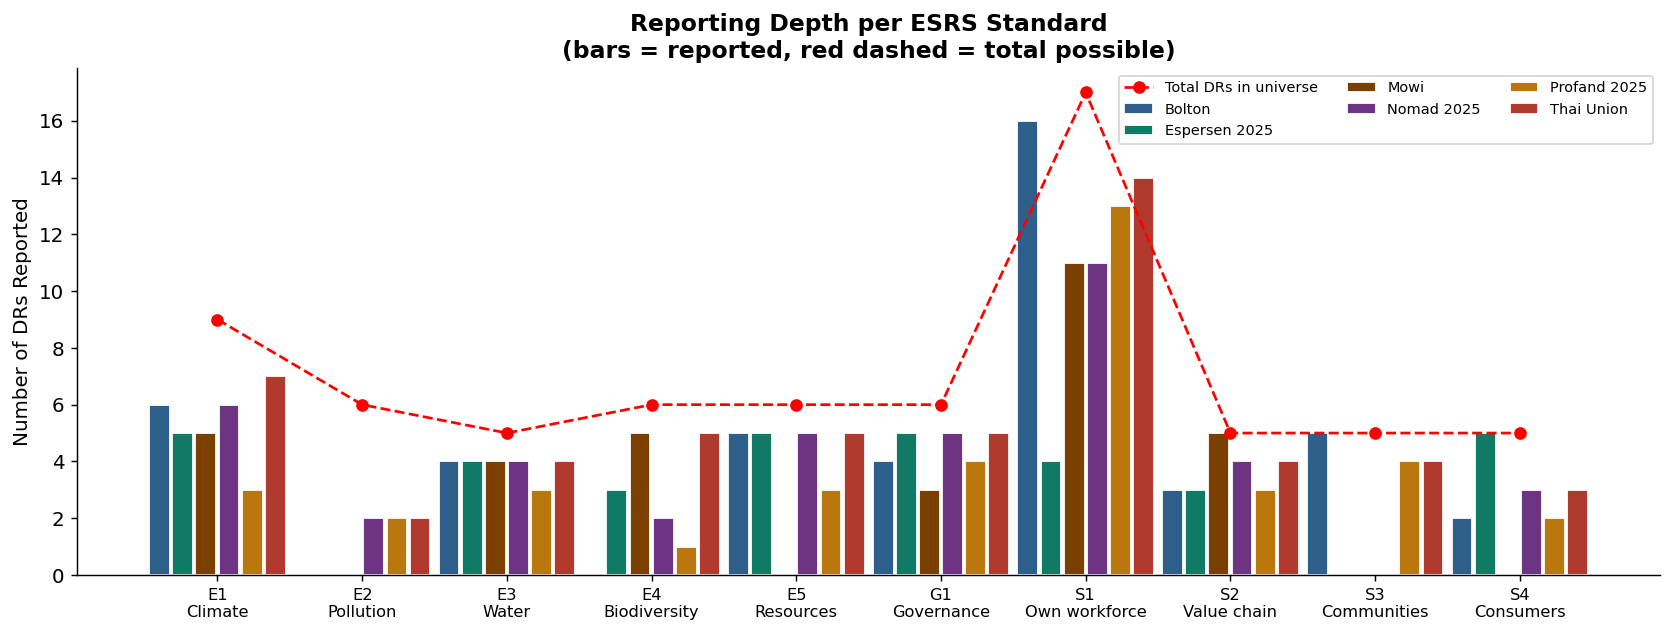

Reporting depth (absolute DRs per company per standard):


,E1,E2,E3,E4,E5,G1,S1,S2,S3,S4
Bolton,6,0,4,0,5,4,16,3,5,2
Espersen 2025,5,0,4,3,5,5,4,3,0,5
Mowi,5,0,4,5,0,3,11,5,0,0
Nomad 2025,6,2,4,2,5,5,11,4,0,3
Profand 2025,3,2,3,1,3,4,13,3,4,2
Thai Union,7,2,4,5,5,5,14,4,4,3


In [11]:
# Reported DRs per company per standard (absolute count)
depth = heatmap_count.astype(int)

fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(all_standards))
width = 0.16
offsets = np.linspace(-(len(COMPANIES)-1)/2, (len(COMPANIES)-1)/2, len(COMPANIES)) * width

for i, company in enumerate(COMPANIES):
    vals = [depth.loc[company, std] for std in all_standards]
    ax.bar(x + offsets[i], vals, width=width*0.9,
           label=company, color=COMPANY_COLORS.get(company,'#666'),
           edgecolor='white')

# Add universe size as dots
universe_sizes = [len([dr for dr in all_drs if dr[:2]==std]) for std in all_standards]
ax.plot(x, universe_sizes, 'r--o', markersize=6, linewidth=1.5,
        label='Total DRs in universe', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([STD_LABELS.get(s,s) for s in all_standards], fontsize=9)
ax.set_ylabel('Number of DRs Reported')
ax.set_title('Reporting Depth per ESRS Standard\n(bars = reported, red dashed = total possible)')
ax.legend(fontsize=8, ncol=3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('chart_depth.png', bbox_inches='tight', dpi=150)
plt.show()

print('Reporting depth (absolute DRs per company per standard):')
display(depth)

## Cell 9 — Environmental / Social / Governance split

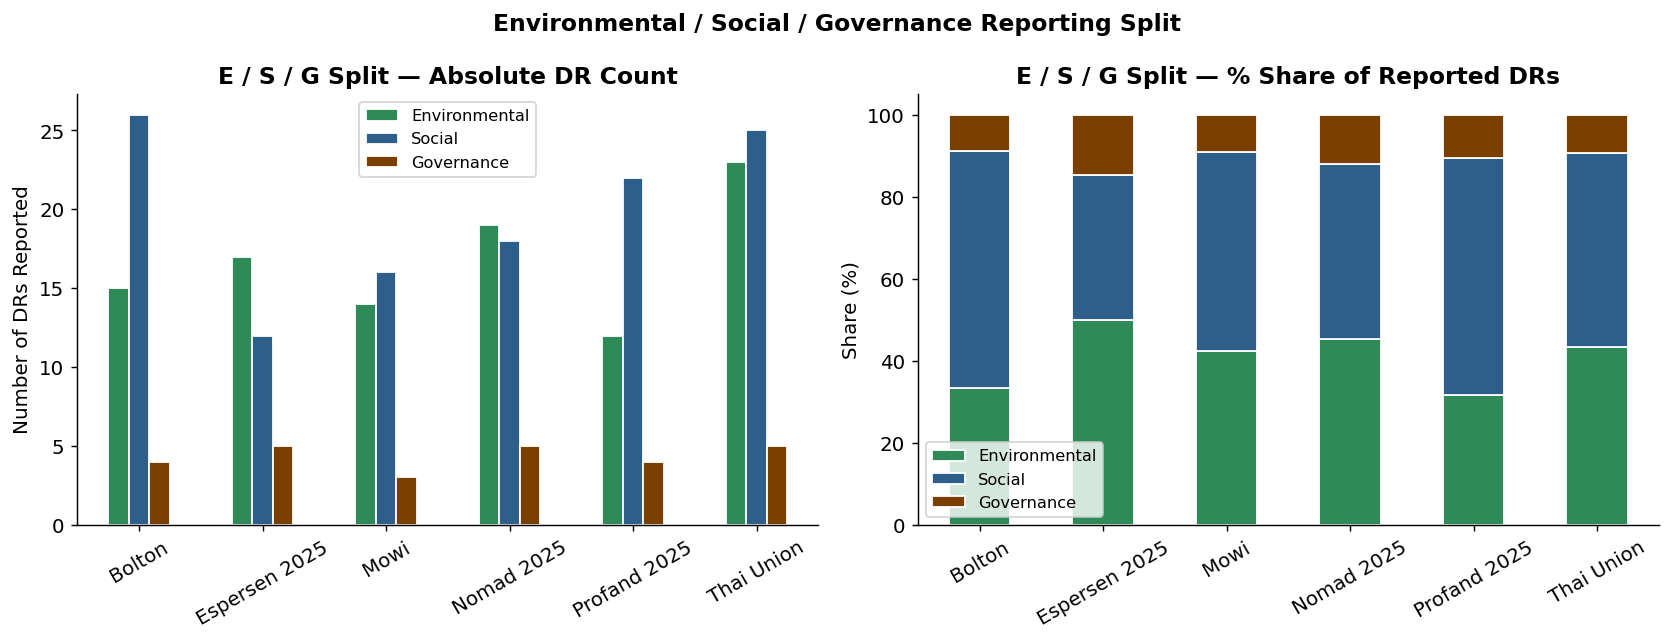

E/S/G breakdown (absolute):


,Environmental,Social,Governance
Bolton,15,26,4
Espersen 2025,17,12,5
Mowi,14,16,3
Nomad 2025,19,18,5
Profand 2025,12,22,4
Thai Union,23,25,5



E/S/G breakdown (%):


,Environmental,Social,Governance
Bolton,33.3,57.8,8.9
Espersen 2025,50.0,35.3,14.7
Mowi,42.4,48.5,9.1
Nomad 2025,45.2,42.9,11.9
Profand 2025,31.6,57.9,10.5
Thai Union,43.4,47.2,9.4


In [12]:
ESG_MAP = {
    'E1':'Environmental','E2':'Environmental','E3':'Environmental',
    'E4':'Environmental','E5':'Environmental',
    'S1':'Social','S2':'Social','S3':'Social','S4':'Social',
    'G1':'Governance'
}
ESG_COLORS = {'Environmental':'#2E8B57','Social':'#2E5F8A','Governance':'#7B3F00'}

esg_df = pd.DataFrame(index=COMPANIES, columns=['Environmental','Social','Governance'], data=0)
for company in COMPANIES:
    comp_drs = df[df['Company']==company]['DR'].str.strip().unique()
    for dr in comp_drs:
        std = dr[:2]
        esg = ESG_MAP.get(std)
        if esg:
            esg_df.loc[company, esg] += 1

esg_df = esg_df.astype(int)
esg_pct = esg_df.div(esg_df.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Absolute
esg_df.plot(kind='bar', ax=ax1, color=[ESG_COLORS[c] for c in esg_df.columns],
            edgecolor='white')
ax1.set_title('E / S / G Split — Absolute DR Count')
ax1.set_ylabel('Number of DRs Reported')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=9)
sns.despine(ax=ax1)

# Percentage stacked
esg_pct.plot(kind='bar', stacked=True, ax=ax2,
             color=[ESG_COLORS[c] for c in esg_pct.columns],
             edgecolor='white')
ax2.set_title('E / S / G Split — % Share of Reported DRs')
ax2.set_ylabel('Share (%)')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

plt.suptitle('Environmental / Social / Governance Reporting Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_esg_split.png', bbox_inches='tight', dpi=150)
plt.show()

print('E/S/G breakdown (absolute):')
display(esg_df)
print()
print('E/S/G breakdown (%):')
display(esg_pct.round(1))

## Cell 10 — DR frequency ranking (most/least commonly reported)

=== Top 15 most commonly reported DRs ===


,DR,Topic,N_Companies_Reporting,Reported_By
DR,,,,
E1-5,E1-5,E1,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E1-4,E1-4,E1,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E1-6,E1-6,E1,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E3-3,E3-3,E3,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E3-4,E3-4,E3,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E3-2,E3-2,E3,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
S2-1,S2-1,S2,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
S2-3,S2-3,S2,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
S1-14,S1-14,S1,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."



=== 15 least reported DRs (excluding zeros) ===


,DR,Topic,N_Companies_Reporting,Reported_By
DR,,,,
S3-3,S3-3,S3,3,"Bolton, Profand 2025, Thai Union"
E4-1,E4-1,E4,3,"Espersen 2025, Mowi, Thai Union"
E2-4,E2-4,E2,3,"Nomad 2025, Profand 2025, Thai Union"
E1-1,E1-1,E1,2,"Bolton, Mowi"
E1-7,E1-7,E1,2,"Nomad 2025, Thai Union"
E2-3,E2-3,E2,2,"Profand 2025, Thai Union"
E4-4,E4-4,E4,2,"Mowi, Thai Union"
S1-15,S1-15,S1,2,"Bolton, Profand 2025"
S2-5,S2-5,S2,2,"Espersen 2025, Mowi"


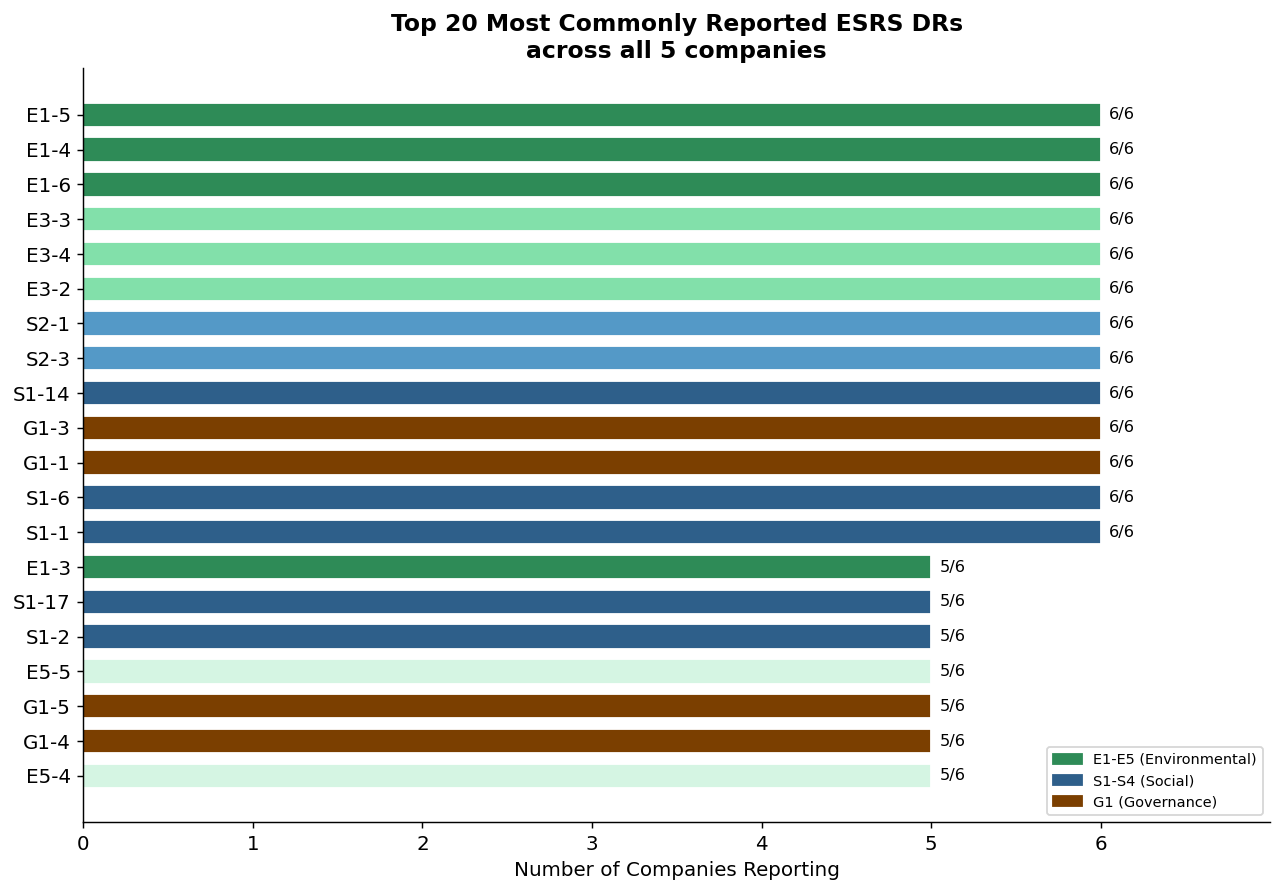

In [13]:
freq = coverage[['N_Companies_Reporting','Topic']].copy()
freq = freq.sort_values('N_Companies_Reporting', ascending=False)
freq['DR'] = freq.index
freq['Reported_By'] = freq.apply(
    lambda r: ', '.join([c for c in COMPANIES if coverage.loc[r.name, c]==1]), axis=1)

print('=== Top 15 most commonly reported DRs ===')
display(freq.head(15)[['DR','Topic','N_Companies_Reporting','Reported_By']])

print()
print('=== 15 least reported DRs (excluding zeros) ===')
display(freq[freq['N_Companies_Reporting']>0].tail(15)[['DR','Topic','N_Companies_Reporting','Reported_By']])

# ── Chart: top 20 most reported ───────────────────────────────────────────────
top20 = freq.head(20).copy()
top20_colors = top20['Topic'].map({
    'E1':'#2E8B57','E2':'#52BE80','E3':'#82E0AA','E4':'#A9DFBF','E5':'#D5F5E3',
    'S1':'#2E5F8A','S2':'#5499C7','S3':'#85C1E9','S4':'#AED6F1',
    'G1':'#7B3F00'
})

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20['DR'][::-1], top20['N_Companies_Reporting'][::-1],
               color=top20_colors[::-1].values, edgecolor='white', height=0.7)
for bar, val in zip(bars, top20['N_Companies_Reporting'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{int(val)}/{n_companies}', va='center', fontsize=9)

ax.set_xlabel('Number of Companies Reporting')
ax.set_title('Top 20 Most Commonly Reported ESRS DRs\nacross all 5 companies')
ax.set_xlim(0, n_companies + 1)
ax.set_xticks(range(0, n_companies+1))

# Legend for topic colours
topic_colors = {'E1-E5 (Environmental)':'#2E8B57','S1-S4 (Social)':'#2E5F8A','G1 (Governance)':'#7B3F00'}
patches = [mpatches.Patch(color=v, label=k) for k,v in topic_colors.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('chart_frequency.png', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
filtered_drs = coverage[coverage['N_Companies_Reporting'].isin([n_companies-1, n_companies])].index.tolist()

print(f"DRs reported by (n-1) or n companies: {filtered_drs}")

DRs reported by (n-1) or n companies: ['E1-3', 'E1-4', 'E1-5', 'E1-6', 'E3-1', 'E3-2', 'E3-3', 'E3-4', 'E5-2', 'E5-4', 'E5-5', 'G1-1', 'G1-3', 'G1-4', 'G1-5', 'S1-1', 'S1-14', 'S1-17', 'S1-2', 'S1-3', 'S1-4', 'S1-6', 'S1-9', 'S2-1', 'S2-2', 'S2-3']


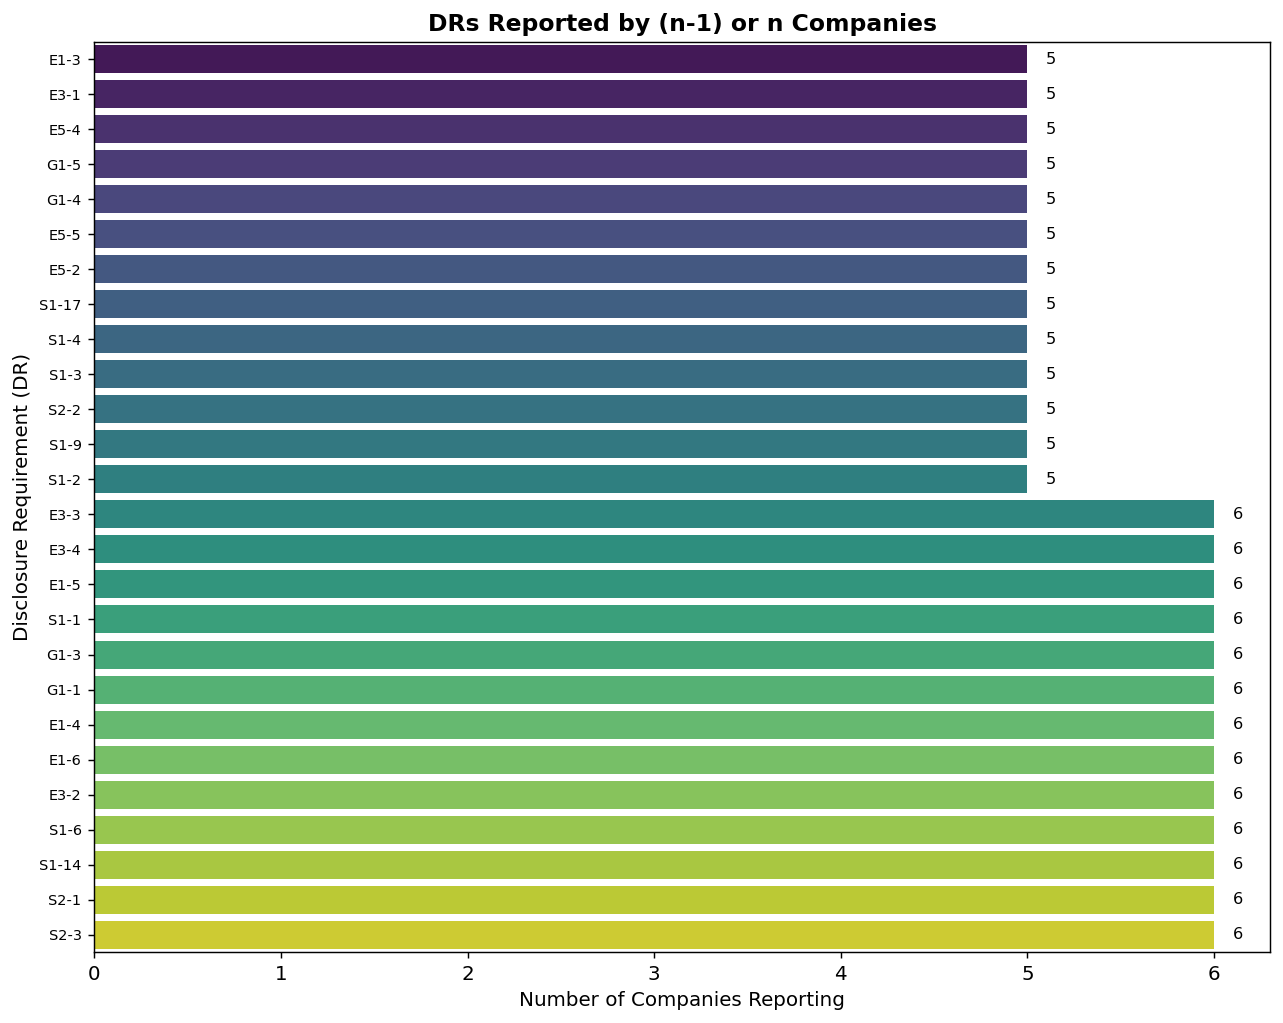

In [15]:
filtered_drs_df = coverage[coverage['N_Companies_Reporting'].isin([n_companies-1, n_companies])].copy()

# Sort by number of companies reporting for better visualization
filtered_drs_df = filtered_drs_df.sort_values(by='N_Companies_Reporting', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    x=filtered_drs_df['N_Companies_Reporting'],
    y=filtered_drs_df.index,
    palette='viridis',
    ax=ax
)

ax.set_title('DRs Reported by (n-1) or n Companies')
ax.set_xlabel('Number of Companies Reporting')
ax.set_ylabel('Disclosure Requirement (DR)')
ax.tick_params(axis='y', labelsize=8)

# Add value labels to the bars
for index, value in enumerate(filtered_drs_df['N_Companies_Reporting']):
    ax.text(value + 0.1, index, str(int(value)), color='black', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart_drs_4_or_5_companies.png', bbox_inches='tight', dpi=150)
plt.show()

The chart above visualizes the Disclosure Requirements (DRs) that are reported by either 4 or 5 of the analyzed companies. This helps in identifying the most commonly reported DRs within this specific range, indicating areas of higher consensus in reporting among the companies.

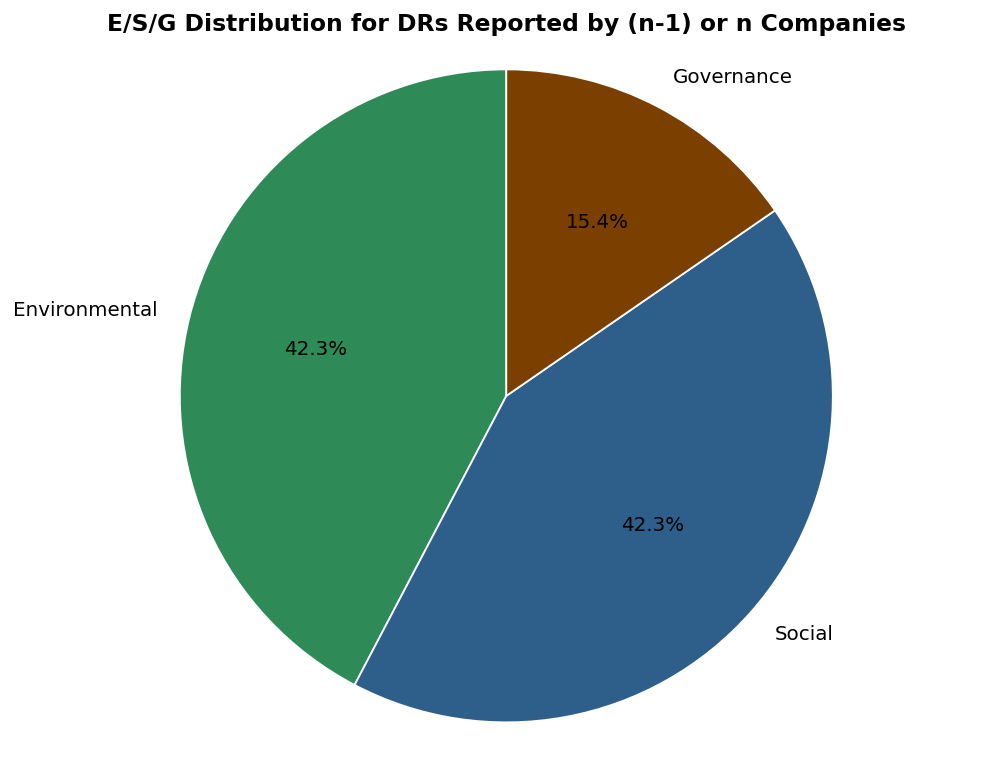

ESG Distribution for DRs reported by (n-1) or n companies:


,Count
DR,
Environmental,11
Social,11
Governance,4


In [16]:
filtered_drs_topics = filtered_drs_df.index.str[:2] # Extract topics from DRs

# Map topics to ESG categories
filtered_esg_distribution = filtered_drs_topics.map(ESG_MAP).value_counts()

# Plotting the distribution
fig, ax = plt.subplots(figsize=(8, 6))

# Use ESG_COLORS for consistency, filtering for categories present
colors = [ESG_COLORS[cat] for cat in filtered_esg_distribution.index if cat in ESG_COLORS]

# Pie chart
ax.pie(
    filtered_esg_distribution,
    labels=filtered_esg_distribution.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('E/S/G Distribution for DRs Reported by (n-1) or n Companies')
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.savefig('chart_filtered_esg_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print('ESG Distribution for DRs reported by (n-1) or n companies:')
display(filtered_esg_distribution.to_frame(name='Count'))

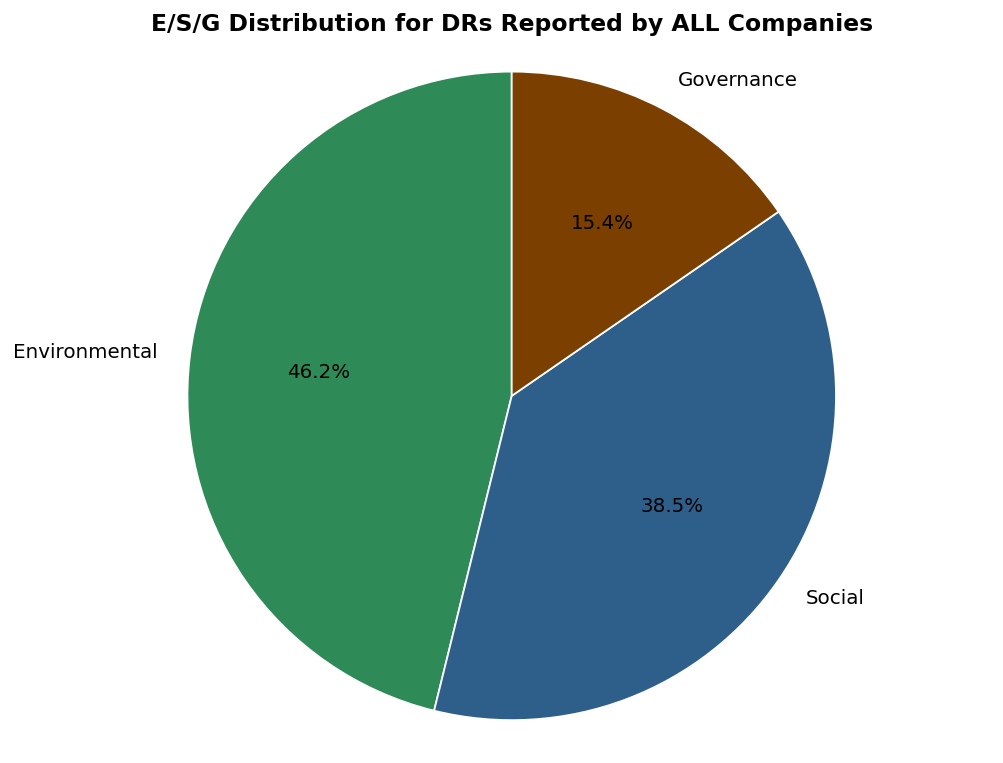

ESG Distribution for DRs reported by ALL 5 companies:


,Count
DR,
Environmental,6
Social,5
Governance,2


In [17]:
# Filter for DRs reported by exactly 5 companies
filtered_drs_5_companies_df = coverage[coverage['N_Companies_Reporting'] == n_companies].copy()

# Extract topics from these DRs
filtered_drs_5_companies_topics = filtered_drs_5_companies_df.index.str[:2]

# Map topics to ESG categories
filtered_esg_distribution_5_companies = filtered_drs_5_companies_topics.map(ESG_MAP).value_counts()

# Plotting the distribution
fig, ax = plt.subplots(figsize=(8, 6))

# Use ESG_COLORS for consistency, filtering for categories present
colors_5_companies = [ESG_COLORS[cat] for cat in filtered_esg_distribution_5_companies.index if cat in ESG_COLORS]

# Pie chart
ax.pie(
    filtered_esg_distribution_5_companies,
    labels=filtered_esg_distribution_5_companies.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_5_companies,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('E/S/G Distribution for DRs Reported by ALL Companies')
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.savefig('chart_filtered_esg_distribution_5_companies.png', bbox_inches='tight', dpi=150)
plt.show()

print('ESG Distribution for DRs reported by ALL 5 companies:')
display(filtered_esg_distribution_5_companies.to_frame(name='Count'))

In [18]:
master_universal_drs = master[master['DR'].isin(universal)].copy()
display(master_universal_drs)

,ESRS_ID,ESRS_LAYER,Topic,Subtopic,DR,Paragraph,Related_AR,Official_Datapoint_Name,Data_Type,Conditional_or_Alternative_DP,May_Voluntary,Appendix_B_Linkage,Phasing_LT_750,Phasing_All,Quant_or_Qual,Processing_Relevance_Default,Priority_Screen,Keyword_1,Keyword_2,Keyword_3
55,E1.MDR-T_01-13,Exclude,E1,NaN,E1-4,32,NaN,Tracking effectiveness of policies and actions...,MDR-T,NaN,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
56,E1-4_01,Keep,E1,NaN,E1-4,33,AR 27-AR 29,Disclosure of whether and how GHG emissions re...,narrative,NaN,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
57,E1-4_02,Keep,E1,NaN,E1-4,34 a + 34 b,"AR 23-AR 24, AR 27-AR 29, AR31",Tables: Multiple Dimensions (baseline year and...,Table,Conditional,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
58,E1-4_03,Keep,E1,NaN,E1-4,34 a + 34 b,NaN,Absolute value of total Greenhouse gas emissio...,Table/ghgEmissions,Conditional,NaN,SFDR+PILLAR 3+ BENCHMARK,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
59,E1-4_04,Keep,E1,NaN,E1-4,34 a + 34 b,NaN,Percentage of total Greenhouse gas emissions r...,Table/percent,Conditional,NaN,SFDR+PILLAR 3+ BENCHMARK,NaN,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,G1-3_05,Keep,G1,NaN,G1-3,20,NaN,Information about how policies are communicate...,narrative,NaN,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
963,G1-3_06,Keep,G1,NaN,G1-3,21 a,NaN,"Information about nature, scope and depth of a...",narrative,NaN,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
964,G1-3_07,Keep,G1,NaN,G1-3,21 b,AR 4,Percentage of functions-at-risk covered by tra...,Percent,NaN,NaN,NaN,NaN,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN
965,G1-3_08,Keep,G1,NaN,G1-3,21 c,NaN,"Information about members of administrative, s...",narrative,NaN,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN


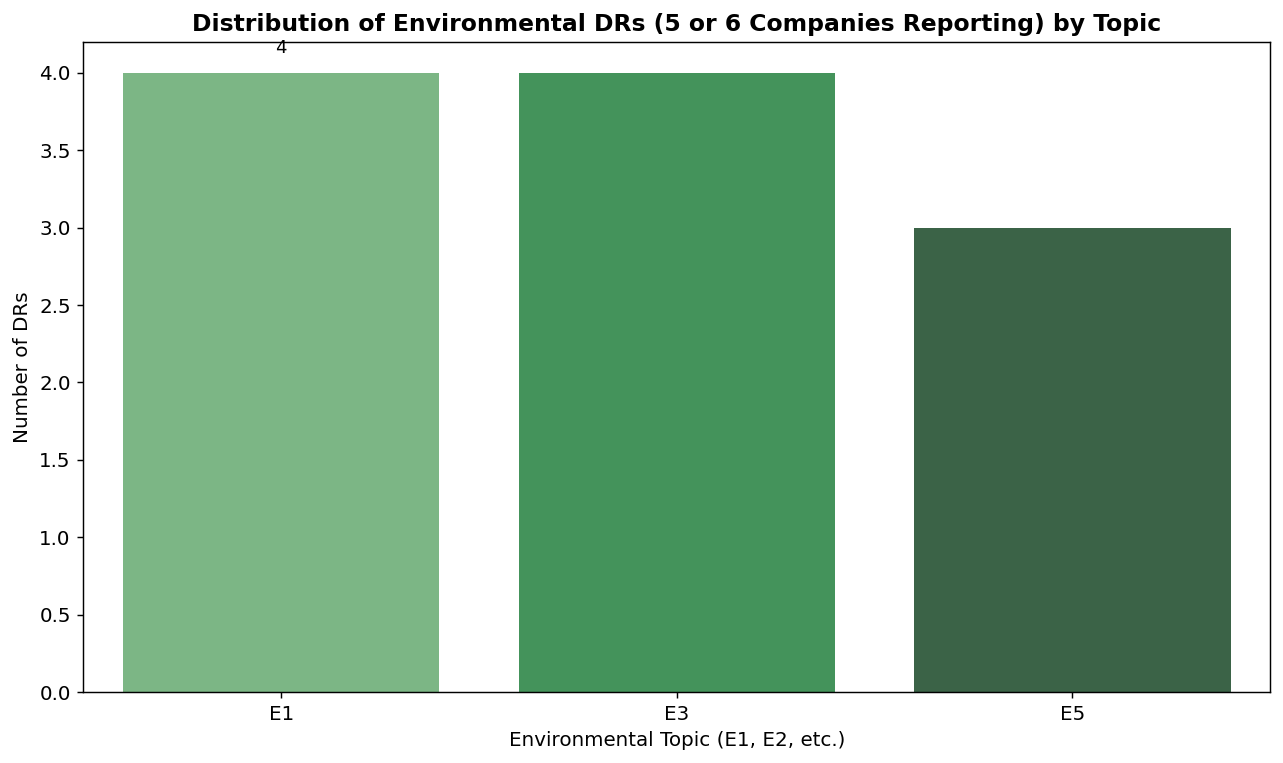

Breakdown of Environmental DRs (4 or 5 Companies Reporting) by Topic:


,Count
E1,4
E3,4
E5,3


In [19]:
environmental_filtered_drs = [dr for dr in filtered_drs_df.index if ESG_MAP.get(dr[:2]) == 'Environmental']
environmental_topic_distribution = pd.Series(environmental_filtered_drs).str[:2].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=environmental_topic_distribution.index,
    y=environmental_topic_distribution.values,
    palette='Greens_d', # Using a green palette for environmental topics
    ax=ax
)

ax.set_title('Distribution of Environmental DRs (5 or 6 Companies Reporting) by Topic')
ax.set_xlabel('Environmental Topic (E1, E2, etc.)')
ax.set_ylabel('Number of DRs')

# Add value labels to the bars
for bar in ax.containers[0]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            int(bar.get_height()), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('chart_environmental_drs_by_topic.png', bbox_inches='tight', dpi=150)
plt.show()

print('Breakdown of Environmental DRs (4 or 5 Companies Reporting) by Topic:')
display(environmental_topic_distribution.to_frame(name='Count'))

In [20]:
filtered_by_count = freq[freq['N_Companies_Reporting'] >= n_companies-1]
environmental_e4_drs = freq[(freq['Topic'] == 'E4') & (freq['N_Companies_Reporting'] >= 0)]


# Combine the two filtered dataframes and remove duplicates
combined_filtered_drs = pd.concat([filtered_by_count, environmental_e4_drs]).drop_duplicates(subset=['DR'])

# Sort for better readability, e.g., by Topic and then N_Companies_Reporting
combined_filtered_drs = combined_filtered_drs.sort_values(by=['Topic', 'N_Companies_Reporting'], ascending=[True, False])

# Select the requested columns
result_table = combined_filtered_drs[['DR', 'Topic', 'N_Companies_Reporting', 'Reported_By']]

display(environmental_e4_drs)

,N_Companies_Reporting,Topic,DR,Reported_By
DR,,,,
E4-3,4,E4,E4-3,"Espersen 2025, Mowi, Nomad 2025, Thai Union"
E4-2,4,E4,E4-2,"Espersen 2025, Mowi, Nomad 2025, Thai Union"
E4-5,3,E4,E4-5,"Mowi, Profand 2025, Thai Union"
E4-1,3,E4,E4-1,"Espersen 2025, Mowi, Thai Union"
E4-4,2,E4,E4-4,"Mowi, Thai Union"
E4-6,0,E4,E4-6,


In [21]:
result_table = filtered_by_count.copy()

print('Updated result_table:')
display(result_table)

Updated result_table:


,N_Companies_Reporting,Topic,DR,Reported_By
DR,,,,
E1-5,6,E1,E1-5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E1-4,6,E1,E1-4,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E1-6,6,E1,E1-6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E3-3,6,E3,E3-3,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E3-4,6,E3,E3-4,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
E3-2,6,E3,E3-2,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
S2-1,6,S2,S2-1,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
S2-3,6,S2,S2-3,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."
S1-14,6,S1,S1-14,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa..."


In [22]:
print(f"Total DRs in the table: {len(result_table)}")
print("\nDRs per Topic:")
display(result_table['Topic'].value_counts().to_frame(name='Number of DRs'))

Total DRs in the table: 26

DRs per Topic:


,Number of DRs
Topic,
S1,8
E1,4
E3,4
G1,4
S2,3
E5,3


=== 26 DRs in shortlist, distributed across topics ===


,# DRs in shortlist
Topic,
E1,4
E2,0
E3,4
E4,0
E5,3
S1,8
S2,3
S3,0
S4,0


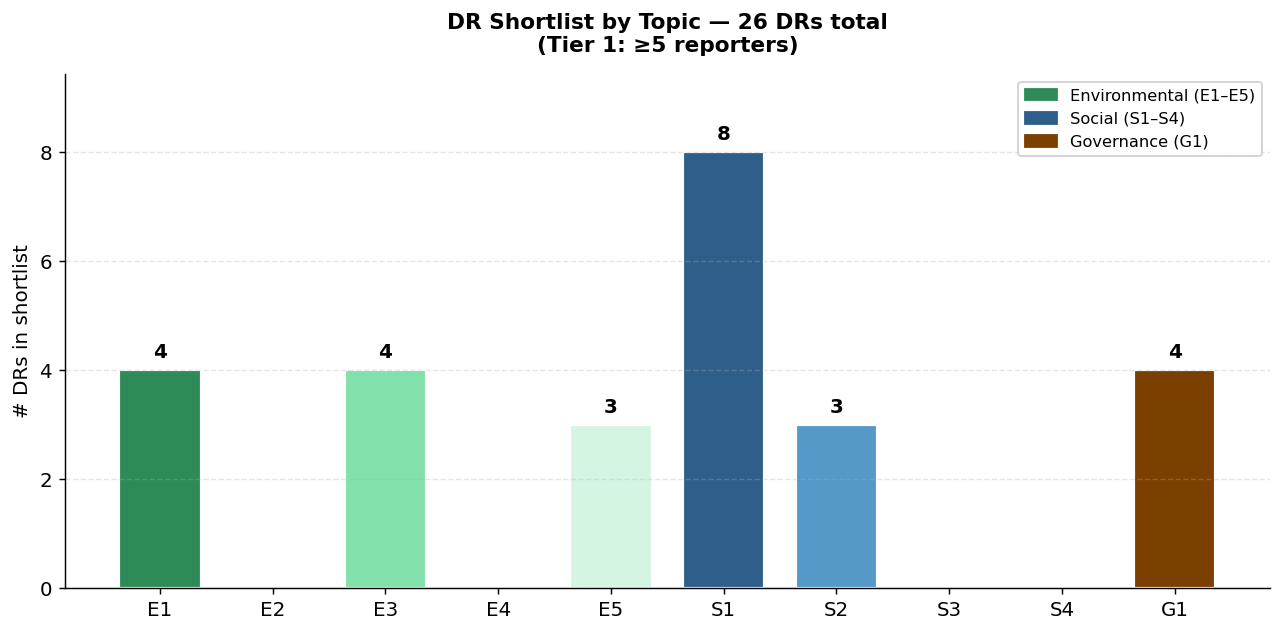

In [23]:
# ── DR shortlist breakdown by Topic ──────────────────────────────────────────
topic_order  = ['E1','E2','E3','E4','E5','S1','S2','S3','S4','G1']
topic_colors = {
    'E1':'#2E8B57','E2':'#52BE80','E3':'#82E0AA','E4':'#A9DFBF','E5':'#D5F5E3',
    'S1':'#2E5F8A','S2':'#5499C7','S3':'#85C1E9','S4':'#AED6F1',
    'G1':'#7B3F00'
}

dr_per_topic = result_table['Topic'].value_counts().reindex(topic_order, fill_value=0)

print(f'=== {len(result_table)} DRs in shortlist, distributed across topics ===')
display(dr_per_topic.to_frame('# DRs in shortlist'))

# ── Chart ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dr_per_topic.index, dr_per_topic.values,
              color=[topic_colors[t] for t in dr_per_topic.index],
              edgecolor='white', linewidth=1.2, width=0.72)

# Value labels on top of each bar
for bar, val in zip(bars, dr_per_topic.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                str(int(val)), ha='center', va='bottom',
                fontsize=11, fontweight='bold')

ax.set_title(f'DR Shortlist by Topic — {len(result_table)} DRs total\n'
             f'(Tier 1: ≥5 reporters)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('# DRs in shortlist')
ax.set_ylim(0, max(dr_per_topic.values) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# ESG legend underneath
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#2E8B57', label='Environmental (E1–E5)'),
    mpatches.Patch(color='#2E5F8A', label='Social (S1–S4)'),
    mpatches.Patch(color='#7B3F00', label='Governance (G1)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('chart_shortlist_drs_by_topic.png', bbox_inches='tight', dpi=150)
plt.show()

In [24]:
## LIST OF EXCLUDED TOPICS
topics_to_include = ['E2', 'E4', 'S3', 'S4']

# Filter the 'freq' DataFrame for the specified topics
previously_excluded_drs = freq[freq['Topic'].isin(topics_to_include)].copy()

# Sort for better readability, e.g., by Topic and then N_Companies_Reporting
previously_excluded_drs = previously_excluded_drs.sort_values(by=['Topic', 'N_Companies_Reporting'], ascending=[True, False])

print('DRs from E2, E4, S3, and S4 topics:')
display(previously_excluded_drs[['DR', 'Topic', 'N_Companies_Reporting', 'Reported_By']])

DRs from E2, E4, S3, and S4 topics:


,DR,Topic,N_Companies_Reporting,Reported_By
DR,,,,
E2-4,E2-4,E2,3,"Nomad 2025, Profand 2025, Thai Union"
E2-3,E2-3,E2,2,"Profand 2025, Thai Union"
E2-2,E2-2,E2,1,Nomad 2025
E2-5,E2-5,E2,0,
E2-1,E2-1,E2,0,
E2-6,E2-6,E2,0,
E4-3,E4-3,E4,4,"Espersen 2025, Mowi, Nomad 2025, Thai Union"
E4-2,E4-2,E4,4,"Espersen 2025, Mowi, Nomad 2025, Thai Union"
E4-5,E4-5,E4,3,"Mowi, Profand 2025, Thai Union"


In [25]:
## EXCELL GENERATION
output_excel_filename = 'previously_excluded_drs.xlsx'
previously_excluded_drs.to_excel(output_excel_filename, index=False)
print(f'✅ Exported `previously_excluded_drs` to {output_excel_filename}')
files.download(output_excel_filename)

✅ Exported `previously_excluded_drs` to previously_excluded_drs.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 12 — Unique DRs per company (what only they report)

In [26]:
print('=== DRs reported UNIQUELY by each company (not reported by any other) ===')
print()
unique_summary = {}
for company in COMPANIES:
    unique_drs = coverage[
        (coverage[company] == 1) &
        (coverage['N_Companies_Reporting'] == 1)
    ].index.tolist()
    unique_summary[company] = unique_drs
    print(f'{company} ({len(unique_drs)} unique DRs):')
    if unique_drs:
        print(f'  {unique_drs}')
    else:
        print('  (none — all reported DRs are shared with at least one other company)')
    print()

=== DRs reported UNIQUELY by each company (not reported by any other) ===

Bolton (3 unique DRs):
  ['S1-10', 'S1-11', 'S3-5']

Espersen 2025 (1 unique DRs):
  ['S4-5']

Mowi (0 unique DRs):
  (none — all reported DRs are shared with at least one other company)

Nomad 2025 (1 unique DRs):
  ['E2-2']

Profand 2025 (0 unique DRs):
  (none — all reported DRs are shared with at least one other company)

Thai Union (1 unique DRs):
  ['E1-9']



## Cell 13 — Summary statistics table

In [27]:
summary_rows = []
for company in COMPANIES:
    reported    = int(coverage[company].sum())
    total       = len(all_drs)
    cov_rate    = round(reported/total*100, 1)
    n_unique    = len(unique_summary[company])
    n_universal = int(coverage[
        (coverage[company]==1) &
        (coverage['N_Companies_Reporting']==len(COMPANIES))
    ].shape[0])
    e_count = int(esg_df.loc[company,'Environmental'])
    s_count = int(esg_df.loc[company,'Social'])
    g_count = int(esg_df.loc[company,'Governance'])

    summary_rows.append({
        'Company': company,
        'DRs Reported': reported,
        'Total DR Universe': total,
        'Coverage Rate (%)': cov_rate,
        'Environmental DRs (E)': e_count,
        'Social DRs (S)': s_count,
        'Governance DRs (G)': g_count,
        'Unique DRs (only this co.)': n_unique,
        'Universal DRs (all 5 cos.)': n_universal,
    })

summary = pd.DataFrame(summary_rows).set_index('Company')
print('=== MASTER SUMMARY TABLE ===')
display(summary)

=== MASTER SUMMARY TABLE ===


,DRs Reported,Total DR Universe,Coverage Rate (%),Environmental DRs (E),Social DRs (S),Governance DRs (G),Unique DRs (only this co.),Universal DRs (all 5 cos.)
Company,,,,,,,,
Bolton,45,70,64.3,15,26,4,3,13
Espersen 2025,34,70,48.6,17,12,5,1,13
Mowi,33,70,47.1,14,16,3,0,13
Nomad 2025,42,70,60.0,19,18,5,1,13
Profand 2025,38,70,54.3,12,22,4,0,13
Thai Union,53,70,75.7,23,25,5,1,13


## Cell 14 — Expand shortlist to datapoints (join to ESRS_MASTER)

Take the 36-DR shortlist built above (`result_table`) and pull every datapoint that belongs to those DRs from `ESRS_MASTER`. All original ESRS_MASTER columns are preserved; three provenance columns are added (`N_Companies_Reporting`, `Reported_By`, `Inclusion_Tier`) so the table is self-contained for downstream ranking.

In [28]:
# ── Build provenance dict from result_table (DR-level shortlist from Cell 29) ─
shortlist_drs = sorted(result_table['DR'].tolist())

provenance = {}
for _, row in result_table.iterrows():
    n = int(row['N_Companies_Reporting'])
    tier = f'Tier 1: >={n_companies-1} reporters' if n >= 5 else 'Tier 2: E4 ≥4 rescue'
    provenance[row['DR']] = {
        'N_Companies_Reporting': n,
        'Reported_By': row['Reported_By'],
        'Inclusion_Tier': tier,
    }

# ── Expand: keep only ESRS_MASTER rows whose DR is in the shortlist ──────────
shortlist_dps = master[master['DR'].isin(shortlist_drs)].copy()

# ── Attach provenance columns ────────────────────────────────────────────────
shortlist_dps['N_Companies_Reporting'] = shortlist_dps['DR'].map(lambda d: provenance[d]['N_Companies_Reporting'])
shortlist_dps['Reported_By']           = shortlist_dps['DR'].map(lambda d: provenance[d]['Reported_By'])
shortlist_dps['Inclusion_Tier']        = shortlist_dps['DR'].map(lambda d: provenance[d]['Inclusion_Tier'])

# Reorder: place provenance columns right after the DR column for readability
master_cols = list(master.columns)
prov_cols = ['N_Companies_Reporting', 'Reported_By', 'Inclusion_Tier']
final_cols = []
for c in master_cols:
    final_cols.append(c)
    if c == 'DR':
        final_cols.extend(prov_cols)
shortlist_dps = shortlist_dps[final_cols]

# ── Sanity check: any shortlist DR with no DPs in ESRS_MASTER? ───────────────
drs_with_dps = set(shortlist_dps['DR'].unique())
missing = [dr for dr in shortlist_drs if dr not in drs_with_dps]
if missing:
    print(f'⚠  {len(missing)} shortlist DR(s) have no DPs in ESRS_MASTER:')
    print('  ', ', '.join(missing))
    print()

# ── Summary ──────────────────────────────────────────────────────────────────
print(f'Shortlist DRs:               {len(shortlist_drs)}')
print(f'Total candidate datapoints:  {len(shortlist_dps)}')
print()
print('Datapoints per DR (top 10 largest):')
print(shortlist_dps.groupby('DR').size().sort_values(ascending=False).head(10).to_string())
print()
print('Datapoints per Inclusion Tier:')
print(shortlist_dps.groupby('Inclusion_Tier').size().to_string())
print()
print('Preview (first 15 rows):')
display(shortlist_dps.head(15))

Shortlist DRs:               26
Total candidate datapoints:  368

Datapoints per DR (top 10 largest):
DR
E1-6     35
E1-4     26
E1-5     23
S1-1     23
S1-4     21
S1-6     20
E5-5     18
S1-2     15
S1-17    14
E3-1     13

Datapoints per Inclusion Tier:
Inclusion_Tier
Tier 1: >=5 reporters    368

Preview (first 15 rows):


,ESRS_ID,ESRS_LAYER,Topic,Subtopic,DR,N_Companies_Reporting,Reported_By,Inclusion_Tier,Paragraph,Related_AR,...,May_Voluntary,Appendix_B_Linkage,Phasing_LT_750,Phasing_All,Quant_or_Qual,Processing_Relevance_Default,Priority_Screen,Keyword_1,Keyword_2,Keyword_3
45,E1.MDR-A_01-12,Exclude,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,28,NaN,...,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
46,E1-3_01,Keep,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,29 a,NaN,...,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
47,E1-3_02,Keep,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,AR19d,NaN,...,V,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
48,E1-3_03,Keep,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,29 b,NaN,...,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
49,E1-3_04,Keep,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,29 b,NaN,...,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
50,E1-3_05,Keep,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,AR21,NaN,...,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
51,E1-3_06,Keep,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,29 c i,AR 20,...,NaN,NaN,NaN,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN
52,E1-3_07,Keep,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,"29 c ii,16 c",AR 22,...,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
53,E1-3_08,Keep,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,"29 c iii,16 c",AR 20,...,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN
55,E1.MDR-T_01-13,Exclude,E1,NaN,E1-4,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,32,NaN,...,NaN,NaN,NaN,NaN,Qualitative,NaN,In scope,NaN,NaN,NaN


In [29]:
backbone = shortlist_dps[shortlist_dps['ESRS_LAYER'] == 'Keep'].copy()
print(f'Total datapoints in backbone after filtering: {len(backbone)}')


Total datapoints in backbone after filtering: 356


Analytics on DP

In [30]:
# ── Setup: derive ESG and status flags ────────────────────────────────────────
ws = backbone.copy()
ws['ESG']          = ws['Topic'].map(ESG_MAP)
ws['Is_Voluntary'] = ws['May_Voluntary'].fillna('').astype(str).str.upper().str.contains('V')
ws['Is_Phasing']   = ws['Phasing_All'].fillna('').astype(str).str.strip().ne('')

# Diagnostic: see what raw values exist (worth printing once)
print('Raw values check (in case markers differ from assumed):')
print(f"  May_Voluntary: {ws['May_Voluntary'].value_counts(dropna=False).to_dict()}")
print(f"  Phasing_All:   {ws['Phasing_All'].value_counts(dropna=False).to_dict()}")
print(f"  Quant_or_Qual: {ws['Quant_or_Qual'].value_counts(dropna=False).to_dict()}")
print()

# ══════════════════════════════════════════════════════════════════════════════
# 1. OVERALL COUNTS
# ══════════════════════════════════════════════════════════════════════════════
print(f'■ TOTAL DATAPOINTS IN WORKING SET: {len(ws)}')
print()
print('=== ESG split ===')
display(ws['ESG'].value_counts().to_frame('Count'))

print('=== Per Topic ===')
display(ws['Topic'].value_counts().sort_index().to_frame('Count'))

# ══════════════════════════════════════════════════════════════════════════════
# 2. QUANTITATIVE VS QUALITATIVE
# ══════════════════════════════════════════════════════════════════════════════
print('\n■ QUANTITATIVE vs QUALITATIVE')
print('\n=== Overall ===')
display(ws['Quant_or_Qual'].value_counts(dropna=False).to_frame('Count'))

print('=== Per ESG ===')
qq_esg = pd.crosstab(ws['ESG'], ws['Quant_or_Qual'], dropna=False, margins=True, margins_name='Total')
display(qq_esg)

print('=== Per Topic ===')
qq_topic = pd.crosstab(ws['Topic'], ws['Quant_or_Qual'], dropna=False, margins=True, margins_name='Total')
display(qq_topic)

print('=== Per DR ===')
qq_dr = pd.crosstab(ws['DR'], ws['Quant_or_Qual'], dropna=False)
qq_dr['Total'] = qq_dr.sum(axis=1)
qq_dr['% Quant'] = (qq_dr.get('Quantitative', 0) / qq_dr['Total'] * 100).round(0).astype(int).astype(str) + '%'
display(qq_dr.sort_values('Total', ascending=False))

# ══════════════════════════════════════════════════════════════════════════════
# 3. VOLUNTARY VS MANDATORY
# ══════════════════════════════════════════════════════════════════════════════
print('\n■ VOLUNTARY vs MANDATORY')
print(f"\nOverall: {ws['Is_Voluntary'].sum()} voluntary  |  {(~ws['Is_Voluntary']).sum()} mandatory  "
      f"({ws['Is_Voluntary'].mean()*100:.1f}% voluntary)")

print('\n=== Per Topic ===')
vol_topic = pd.crosstab(ws['Topic'], ws['Is_Voluntary'])
vol_topic.columns = ['Mandatory' if not c else 'Voluntary' for c in vol_topic.columns]
vol_topic['Total'] = vol_topic.sum(axis=1)
display(vol_topic)

# ══════════════════════════════════════════════════════════════════════════════
# 4. PHASING-IN
# ══════════════════════════════════════════════════════════════════════════════
print('\n■ PHASING-IN (Phasing_All)')
print(f"\nOverall: {ws['Is_Phasing'].sum()} phasing-in  |  {(~ws['Is_Phasing']).sum()} currently mandatory  "
      f"({ws['Is_Phasing'].mean()*100:.1f}% phased)")

print('\n=== Per Topic ===')
ph_topic = pd.crosstab(ws['Topic'], ws['Is_Phasing'])
ph_topic.columns = ['Currently mandatory' if not c else 'Phasing-in' for c in ph_topic.columns]
ph_topic['Total'] = ph_topic.sum(axis=1)
display(ph_topic)

Raw values check (in case markers differ from assumed):
  May_Voluntary: {nan: 263, 'V': 93}
  Phasing_All:   {nan: 351, '1 year': 5}
  Quant_or_Qual: {'Qualitative': 300, 'Quantitative': 56}

■ TOTAL DATAPOINTS IN WORKING SET: 356

=== ESG split ===


,Count
ESG,
Environmental,163
Social,152
Governance,41


=== Per Topic ===


,Count
Topic,
E1,90
E3,37
E5,36
G1,41
S1,120
S2,32



■ QUANTITATIVE vs QUALITATIVE

=== Overall ===


...

Quant_or_Qual,Qualitative,Quantitative,Total,% Quant
DR,,,,
E1-6,25,10,35,29%
E1-4,19,5,24,21%
E1-5,17,6,23,26%
S1-1,22,0,22,0%
S1-6,19,1,20,5%
S1-4,20,0,20,0%
E5-5,14,4,18,22%
S1-2,15,0,15,0%
S1-17,12,2,14,14%



■ VOLUNTARY vs MANDATORY

Overall: 93 voluntary  |  263 mandatory  (26.1% voluntary)

=== Per Topic ===


,Mandatory,Voluntary,Total
Topic,,,
E1,85,5,90
E3,21,16,37
E5,24,12,36
G1,31,10,41
S1,79,41,120
S2,23,9,32



■ PHASING-IN (Phasing_All)

Overall: 5 phasing-in  |  351 currently mandatory  (1.4% phased)

=== Per Topic ===


,Currently mandatory,Phasing-in,Total
Topic,,,
E1,90,0,90
E3,37,0,37
E5,36,0,36
G1,41,0,41
S1,115,5,120
S2,32,0,32


In [31]:
# ── Setup: derive ESG and status flags ────────────────────────────────────────
ws = backbone.copy()
ws['ESG']          = ws['Topic'].map(ESG_MAP)
ws['Is_Voluntary'] = ws['May_Voluntary'].fillna('').astype(str).str.upper().str.contains('V')
ws['Is_Phasing']   = ws['Phasing_All'].fillna('').astype(str).str.strip().ne('')

# Diagnostic: see what raw values exist (worth printing once)
print('Raw values check (in case markers differ from assumed):')
print(f"  May_Voluntary: {ws['May_Voluntary'].value_counts(dropna=False).to_dict()}")
print(f"  Phasing_All:   {ws['Phasing_All'].value_counts(dropna=False).to_dict()}")
print(f"  Quant_or_Qual: {ws['Quant_or_Qual'].value_counts(dropna=False).to_dict()}")
print()

# ══════════════════════════════════════════════════════════════════════════════
# 1. OVERALL COUNTS
# ══════════════════════════════════════════════════════════════════════════════
print(f'■ TOTAL DATAPOINTS IN WORKING SET: {len(ws)}')
print()
print('=== ESG split ===')
display(ws['ESG'].value_counts().to_frame('Count'))

print('=== Per Topic ===')
display(ws['Topic'].value_counts().sort_index().to_frame('Count'))

# ══════════════════════════════════════════════════════════════════════════════
# 2. QUANTITATIVE VS QUALITATIVE
# ══════════════════════════════════════════════════════════════════════════════
print('\n■ QUANTITATIVE vs QUALITATIVE')
print('\n=== Overall ===')
display(ws['Quant_or_Qual'].value_counts(dropna=False).to_frame('Count'))

print('=== Per ESG ===')
qq_esg = pd.crosstab(ws['ESG'], ws['Quant_or_Qual'], dropna=False, margins=True, margins_name='Total')
display(qq_esg)

print('=== Per Topic ===')
qq_topic = pd.crosstab(ws['Topic'], ws['Quant_or_Qual'], dropna=False, margins=True, margins_name='Total')
display(qq_topic)

print('=== Per DR ===')
qq_dr = pd.crosstab(ws['DR'], ws['Quant_or_Qual'], dropna=False)
qq_dr['Total'] = qq_dr.sum(axis=1)
qq_dr['% Quant'] = (qq_dr.get('Quantitative', 0) / qq_dr['Total'] * 100).round(0).astype(int).astype(str) + '%'
display(qq_dr.sort_values('Total', ascending=False))

# ══════════════════════════════════════════════════════════════════════════════
# 3. VOLUNTARY VS MANDATORY
# ══════════════════════════════════════════════════════════════════════════════
print('\n■ VOLUNTARY vs MANDATORY')
print(f"\nOverall: {ws['Is_Voluntary'].sum()} voluntary  |  {(~ws['Is_Voluntary']).sum()} mandatory  "
      f"({ws['Is_Voluntary'].mean()*100:.1f}% voluntary)")

print('\n=== Per Topic ===')
vol_topic = pd.crosstab(ws['Topic'], ws['Is_Voluntary'])
vol_topic.columns = ['Mandatory' if not c else 'Voluntary' for c in vol_topic.columns]
vol_topic['Total'] = vol_topic.sum(axis=1)
display(vol_topic)

# ══════════════════════════════════════════════════════════════════════════════
# 4. PHASING-IN
# ══════════════════════════════════════════════════════════════════════════════
print('\n■ PHASING-IN (Phasing_All)')
print(f"\nOverall: {ws['Is_Phasing'].sum()} phasing-in  |  {(~ws['Is_Phasing']).sum()} currently mandatory  "
      f"({ws['Is_Phasing'].mean()*100:.1f}% phased)")

print('\n=== Per Topic ===')
ph_topic = pd.crosstab(ws['Topic'], ws['Is_Phasing'])
ph_topic.columns = ['Currently mandatory' if not c else 'Phasing-in' for c in ph_topic.columns]
ph_topic['Total'] = ph_topic.sum(axis=1)
display(ph_topic)

Raw values check (in case markers differ from assumed):
  May_Voluntary: {nan: 263, 'V': 93}
  Phasing_All:   {nan: 351, '1 year': 5}
  Quant_or_Qual: {'Qualitative': 300, 'Quantitative': 56}

■ TOTAL DATAPOINTS IN WORKING SET: 356

=== ESG split ===


,Count
ESG,
Environmental,163
Social,152
Governance,41


=== Per Topic ===


,Count
Topic,
E1,90
E3,37
E5,36
G1,41
S1,120
S2,32



■ QUANTITATIVE vs QUALITATIVE

=== Overall ===


...

Quant_or_Qual,Qualitative,Quantitative,Total,% Quant
DR,,,,
E1-6,25,10,35,29%
E1-4,19,5,24,21%
E1-5,17,6,23,26%
S1-1,22,0,22,0%
S1-6,19,1,20,5%
S1-4,20,0,20,0%
E5-5,14,4,18,22%
S1-2,15,0,15,0%
S1-17,12,2,14,14%



■ VOLUNTARY vs MANDATORY

Overall: 93 voluntary  |  263 mandatory  (26.1% voluntary)

=== Per Topic ===


,Mandatory,Voluntary,Total
Topic,,,
E1,85,5,90
E3,21,16,37
E5,24,12,36
G1,31,10,41
S1,79,41,120
S2,23,9,32



■ PHASING-IN (Phasing_All)

Overall: 5 phasing-in  |  351 currently mandatory  (1.4% phased)

=== Per Topic ===


,Currently mandatory,Phasing-in,Total
Topic,,,
E1,90,0,90
E3,37,0,37
E5,36,0,36
G1,41,0,41
S1,115,5,120
S2,32,0,32


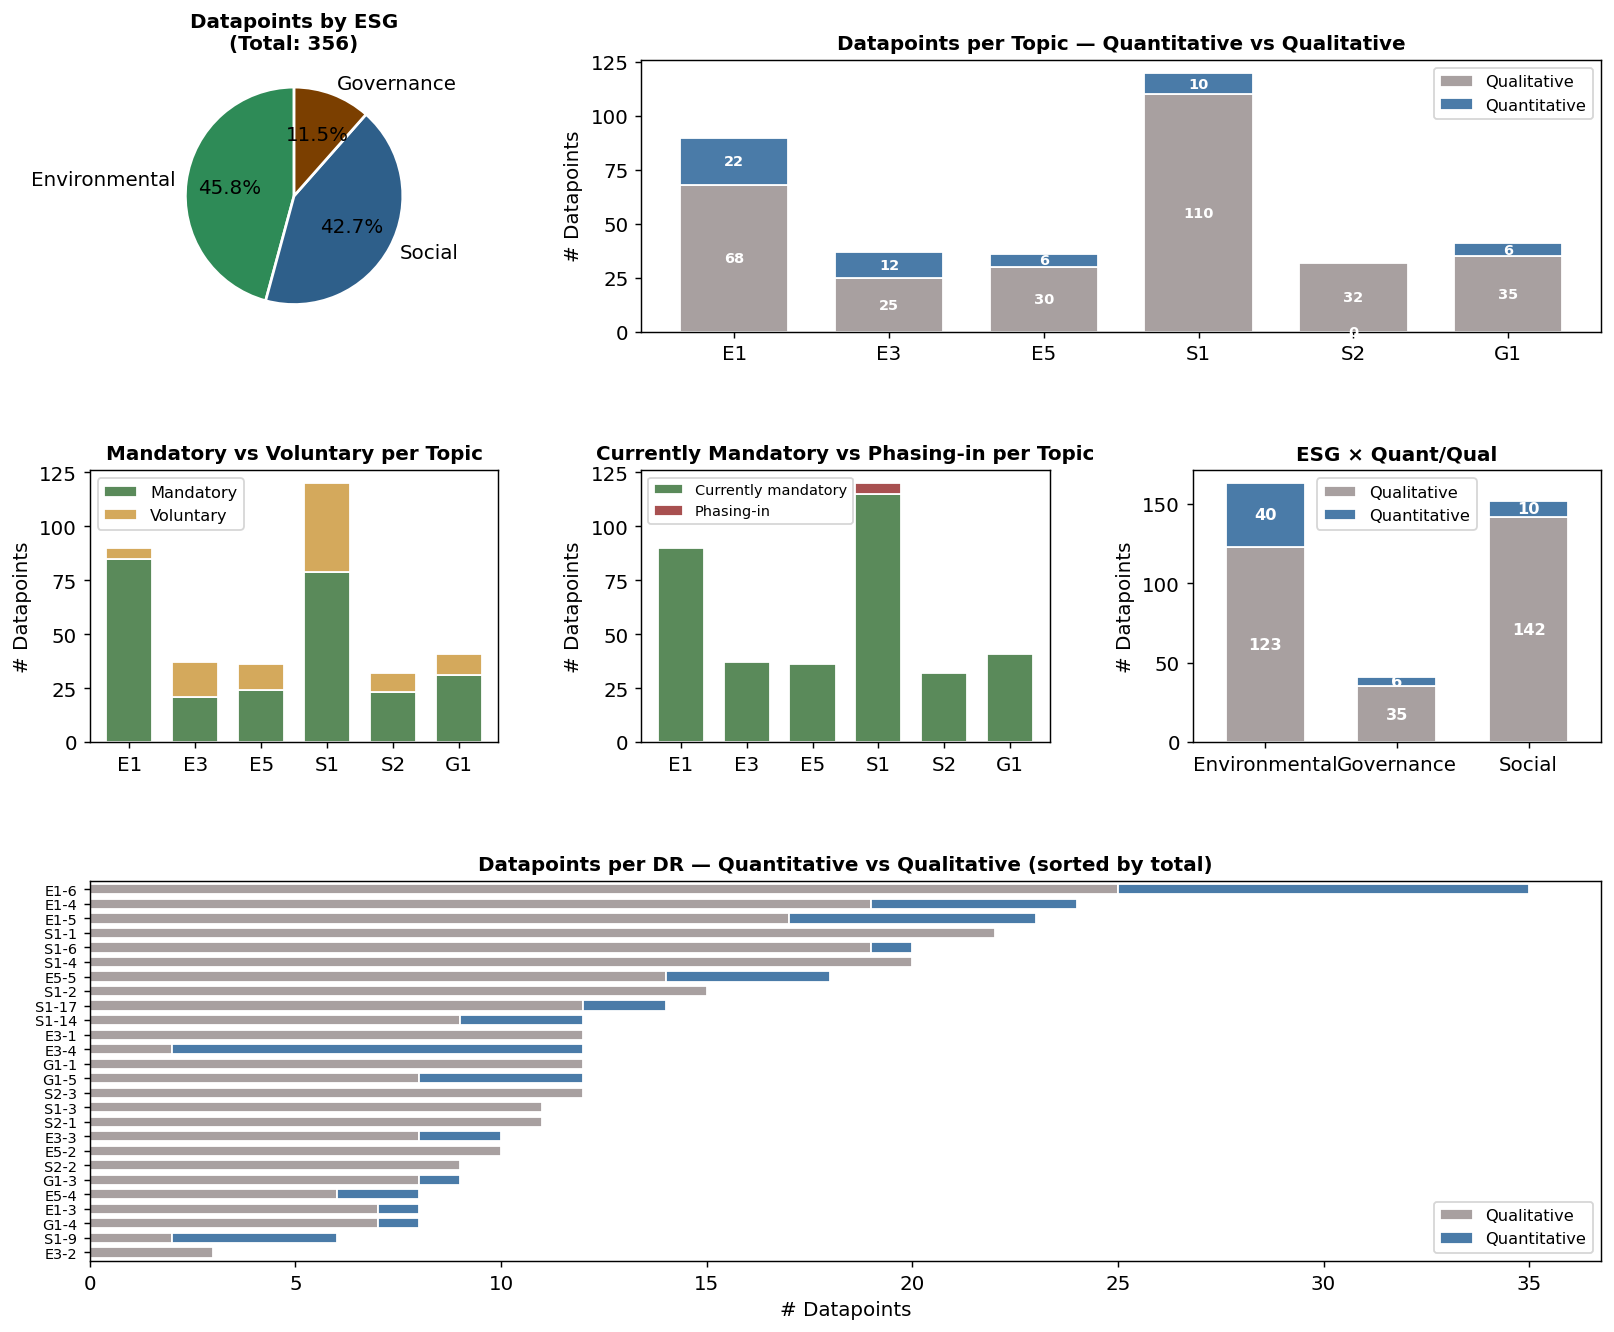

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# CHARTS — 5-panel layout
# ══════════════════════════════════════════════════════════════════════════════

# Topic ordering (canonical ESRS order)
topic_order = ['E1','E2','E3','E4','E5','S1','S2','S3','S4','G1']
topics_present = [t for t in topic_order if t in ws['Topic'].unique()]

# Color palette
QUAL_QUANT_COLORS = {'Quantitative':'#4A7BA8', 'Qualitative':'#A8A0A0'}
STATUS_COLORS_VOL = {'Mandatory':'#5A8A5A', 'Voluntary':'#D4A95C'}
STATUS_COLORS_PH  = {'Currently mandatory':'#5A8A5A', 'Phasing-in':'#A85050'}

fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35,
                      height_ratios=[1, 1, 1.4])

# ── Chart 1: ESG split (pie) ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
esg_counts = ws['ESG'].value_counts()
colors = [ESG_COLORS.get(c, '#888') for c in esg_counts.index]
ax1.pie(esg_counts, labels=esg_counts.index, autopct='%1.1f%%',
        colors=colors, wedgeprops={'edgecolor':'white', 'linewidth':1.5}, startangle=90)
ax1.set_title(f'Datapoints by ESG\n(Total: {len(ws)})', fontsize=11, fontweight='bold')

# ── Chart 2: Topic — Quant vs Qual ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
qq_t = pd.crosstab(ws['Topic'], ws['Quant_or_Qual']).reindex(topics_present)
qq_t.plot(kind='bar', stacked=True, ax=ax2,
          color=[QUAL_QUANT_COLORS.get(c, '#888') for c in qq_t.columns],
          edgecolor='white', width=0.7)
ax2.set_title('Datapoints per Topic — Quantitative vs Qualitative', fontsize=11, fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('# Datapoints')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='', loc='upper right', fontsize=9)
for c in ax2.containers:
    ax2.bar_label(c, label_type='center', fontsize=8, color='white', fontweight='bold')

# ── Chart 3: Topic — Voluntary vs Mandatory ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
vol_t = pd.crosstab(ws['Topic'], ws['Is_Voluntary']).reindex(topics_present)
vol_t.columns = ['Mandatory' if not c else 'Voluntary' for c in vol_t.columns]
vol_t.plot(kind='bar', stacked=True, ax=ax3,
           color=[STATUS_COLORS_VOL.get(c, '#888') for c in vol_t.columns],
           edgecolor='white', width=0.7)
ax3.set_title('Mandatory vs Voluntary per Topic', fontsize=11, fontweight='bold')
ax3.set_xlabel(''); ax3.set_ylabel('# Datapoints')
ax3.tick_params(axis='x', rotation=0)
ax3.legend(title='', fontsize=9)

# ── Chart 4: Topic — Phasing ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ph_t = pd.crosstab(ws['Topic'], ws['Is_Phasing']).reindex(topics_present)
ph_t.columns = ['Currently mandatory' if not c else 'Phasing-in' for c in ph_t.columns]
ph_t.plot(kind='bar', stacked=True, ax=ax4,
          color=[STATUS_COLORS_PH.get(c, '#888') for c in ph_t.columns],
          edgecolor='white', width=0.7)
ax4.set_title('Currently Mandatory vs Phasing-in per Topic', fontsize=11, fontweight='bold')
ax4.set_xlabel(''); ax4.set_ylabel('# Datapoints')
ax4.tick_params(axis='x', rotation=0)
ax4.legend(title='', fontsize=8)

# ── Chart 5: ESG — Quant vs Qual ──────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
qq_esg = pd.crosstab(ws['ESG'], ws['Quant_or_Qual'])
qq_esg.plot(kind='bar', stacked=True, ax=ax5,
            color=[QUAL_QUANT_COLORS.get(c, '#888') for c in qq_esg.columns],
            edgecolor='white', width=0.6)
ax5.set_title('ESG × Quant/Qual', fontsize=11, fontweight='bold')
ax5.set_xlabel(''); ax5.set_ylabel('# Datapoints')
ax5.tick_params(axis='x', rotation=0)
ax5.legend(title='', fontsize=9)
for c in ax5.containers:
    ax5.bar_label(c, label_type='center', fontsize=9, color='white', fontweight='bold')

# ── Chart 6: Per-DR Quant vs Qual (horizontal stacked, full width) ────────────
ax6 = fig.add_subplot(gs[2, :])
qq_dr = pd.crosstab(ws['DR'], ws['Quant_or_Qual'])
# Sort DRs by total descending so the biggest are at the top
qq_dr['_total'] = qq_dr.sum(axis=1)
qq_dr = qq_dr.sort_values('_total', ascending=True).drop(columns='_total')
qq_dr.plot(kind='barh', stacked=True, ax=ax6,
           color=[QUAL_QUANT_COLORS.get(c, '#888') for c in qq_dr.columns],
           edgecolor='white', width=0.7)
ax6.set_title('Datapoints per DR — Quantitative vs Qualitative (sorted by total)',
              fontsize=11, fontweight='bold')
ax6.set_xlabel('# Datapoints'); ax6.set_ylabel('')
ax6.tick_params(axis='y', labelsize=8)
ax6.legend(title='', loc='lower right', fontsize=9)

plt.savefig('chart_dp_analytics.png', bbox_inches='tight', dpi=150)
plt.show()

In [33]:
from PIL import Image
import os
from google.colab import files

output_pdf_filename = 'all_charts_combined.pdf'

# List all generated PNG chart files
chart_files = [
    f for f in os.listdir('.') if f.endswith('.png') and f.startswith('chart_')
]
chart_files.sort() # Sort alphabetically for consistent order

if not chart_files:
    print("No chart PNG files found to combine.")
else:
    print(f"Found {len(chart_files)} chart files: {', '.join(chart_files)}")

    images = []
    for chart_file in chart_files:
        try:
            img = Image.open(chart_file).convert('RGB')
            images.append(img)
        except Exception as e:
            print(f"Could not open {chart_file}: {e}")

    if images:
        # Save the first image, then append the rest
        images[0].save(
            output_pdf_filename, save_all=True, append_images=images[1:], resolution=100.0
        )
        print(f'✅ All charts combined into {output_pdf_filename}')
        files.download(output_pdf_filename)
    else:
        print("No images were successfully processed to create a PDF.")


Found 11 chart files: chart_coverage_rate.png, chart_depth.png, chart_dp_analytics.png, chart_drs_4_or_5_companies.png, chart_environmental_drs_by_topic.png, chart_esg_split.png, chart_filtered_esg_distribution.png, chart_filtered_esg_distribution_5_companies.png, chart_frequency.png, chart_heatmap.png, chart_shortlist_drs_by_topic.png
✅ All charts combined into all_charts_combined.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=== 356 datapoints across 6 topics ===


,# Datapoints
Topic,
E1,90
E2,0
E3,37
E4,0
E5,36
S1,120
S2,32
S3,0
S4,0


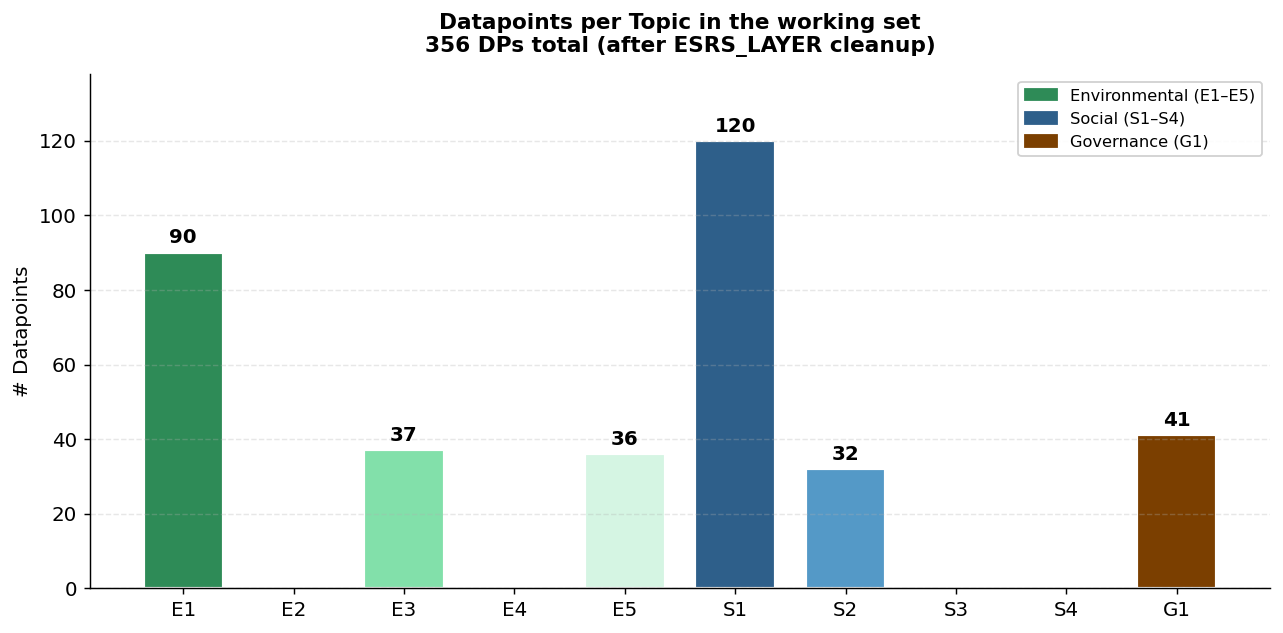

In [34]:
# ── DP count per Topic (from working_set, post ESRS_LAYER cleanup) ───────────
import matplotlib.patches as mpatches

working_set = backbone.copy()

topic_order  = ['E1','E2','E3','E4','E5','S1','S2','S3','S4','G1']
topic_colors = {
    'E1':'#2E8B57','E2':'#52BE80','E3':'#82E0AA','E4':'#A9DFBF','E5':'#D5F5E3',
    'S1':'#2E5F8A','S2':'#5499C7','S3':'#85C1E9','S4':'#AED6F1',
    'G1':'#7B3F00'
}

dp_per_topic = working_set['Topic'].value_counts().reindex(topic_order, fill_value=0)

print(f'=== {len(working_set)} datapoints across {len([t for t in topic_order if dp_per_topic[t]>0])} topics ===')
display(dp_per_topic.to_frame('# Datapoints'))

# ── Chart ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dp_per_topic.index, dp_per_topic.values,
              color=[topic_colors[t] for t in dp_per_topic.index],
              edgecolor='white', linewidth=1.2, width=0.72)

# Value labels on top of each bar
for bar, val in zip(bars, dp_per_topic.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(dp_per_topic.values)*0.012,
                str(int(val)), ha='center', va='bottom',
                fontsize=11, fontweight='bold')

ax.set_title(f'Datapoints per Topic in the working set\n'
             f'{len(working_set)} DPs total (after ESRS_LAYER cleanup)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('# Datapoints')
ax.set_ylim(0, max(dp_per_topic.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# ESG legend
legend_handles = [
    mpatches.Patch(color='#2E8B57', label='Environmental (E1–E5)'),
    mpatches.Patch(color='#2E5F8A', label='Social (S1–S4)'),
    mpatches.Patch(color='#7B3F00', label='Governance (G1)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('chart_dp_per_topic.png', bbox_inches='tight', dpi=150)
plt.show()

In [35]:
output_filename = 'backbone_data.xlsx'
working_set.to_excel(output_filename, index=False)
print(f'✅ Exported backbone DataFrame to {output_filename}')
files.download(output_filename)

✅ Exported backbone DataFrame to backbone_data.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
### Only Quant - table
quantitative_datapoints = ws[ws['Quant_or_Qual'] == 'Quantitative'].copy()
print(f'Total quantitative datapoints: {len(quantitative_datapoints)}')
display(quantitative_datapoints)

Total quantitative datapoints: 56


,ESRS_ID,ESRS_LAYER,Topic,Subtopic,DR,N_Companies_Reporting,Reported_By,Inclusion_Tier,Paragraph,Related_AR,...,Phasing_All,Quant_or_Qual,Processing_Relevance_Default,Priority_Screen,Keyword_1,Keyword_2,Keyword_3,ESG,Is_Voluntary,Is_Phasing
51,E1-3_06,Keep,E1,NaN,E1-3,5,"Bolton, Espersen 2025, Mowi, Nomad 2025, Thai ...",Tier 1: >=5 reporters,29 c i,AR 20,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False
59,E1-4_04,Keep,E1,NaN,E1-4,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,34 a + 34 b,NaN,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False
62,E1-4_07,Keep,E1,NaN,E1-4,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,34 a + 34 b,NaN,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False
65,E1-4_10,Keep,E1,NaN,E1-4,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,34 a + 34 b,NaN,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False
68,E1-4_13,Keep,E1,NaN,E1-4,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,34 a + 34 b,NaN,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False
71,E1-4_16,Keep,E1,NaN,E1-4,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,34 a + 34 b,NaN,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False
84,E1-5_04,Keep,E1,NaN,E1-5,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,AR 34,NaN,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False
89,E1-5_09,Keep,E1,NaN,E1-5,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,AR 34,NaN,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False
95,E1-5_15,Keep,E1,NaN,E1-5,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,AR 34,NaN,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False
98,E1-5_18,Keep,E1,NaN,E1-5,6,"Bolton, Espersen 2025, Mowi, Nomad 2025, Profa...",Tier 1: >=5 reporters,40,AR 36,...,NaN,Quantitative,NaN,In scope,NaN,NaN,NaN,Environmental,False,False


## Cell 14 — Export everything to Excel + download

In [37]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage

OUTPUT = 'ESRS_Coverage_Analytics.xlsx'
wb = openpyxl.Workbook()
wb.remove(wb.active)

BD_S = Side(style='thin', color='CCCCCC')
BD = Border(left=BD_S, right=BD_S, top=BD_S, bottom=BD_S)
WRAP = Alignment(wrap_text=True, vertical='top')
H_FILL = PatternFill('solid', fgColor='2E5F8A')
H_FONT = Font(bold=True, color='FFFFFF', name='Arial', size=10)
D_FONT = Font(name='Arial', size=9)

def write_df_to_sheet(wb, sheet_name, df, freeze='A2'):
    ws = wb.create_sheet(sheet_name)
    for col_idx, col_name in enumerate(df.reset_index().columns, 1):
        c = ws.cell(row=1, column=col_idx, value=str(col_name))
        c.font = H_FONT; c.fill = H_FILL
        c.alignment = Alignment(wrap_text=True, vertical='top', horizontal='center')
        c.border = BD
    for r_idx, row in enumerate(dataframe_to_rows(df.reset_index(), index=False, header=False), 2):
        fill = PatternFill('solid', fgColor='F4F8FC') if r_idx%2==0 else PatternFill('solid', fgColor='FFFFFF')
        for c_idx, val in enumerate(row, 1):
            cell = ws.cell(row=r_idx, column=c_idx, value=val)
            cell.font = D_FONT; cell.fill = fill
            cell.alignment = WRAP; cell.border = BD
        ws.row_dimensions[r_idx].height = 20
    ws.freeze_panes = freeze
    ws.auto_filter.ref = ws.dimensions
    for col in ws.columns:
        ws.column_dimensions[col[0].column_letter].width = 18
    ws.row_dimensions[1].height = 25
    return ws

# Write sheets
write_df_to_sheet(wb, '1_Summary',        summary)
write_df_to_sheet(wb, '2_Coverage_Rate',  coverage_df)
write_df_to_sheet(wb, '3_Heatmap_Pct',    heatmap_pct)
write_df_to_sheet(wb, '4_Heatmap_Count',  heatmap_count.astype(int))
write_df_to_sheet(wb, '5_Coverage_Matrix',coverage[COMPANIES + ['N_Companies_Reporting','Topic']])
write_df_to_sheet(wb, '6_DR_Frequency',   freq[['DR','Topic','N_Companies_Reporting','Reported_By']].reset_index(drop=True))
write_df_to_sheet(wb, '9_ESG_Split',      esg_df)

# Charts sheet
ws_charts = wb.create_sheet('Charts')
ws_charts['A1'].value = 'All charts are embedded below'
ws_charts['A1'].font = H_FONT
chart_files = [
    ('chart_coverage_rate.png', 'A3'),
    ('chart_heatmap.png',       'A30'),
    ('chart_gap_analysis.png',  'A57'),
    ('chart_depth.png',         'A84'),
    ('chart_esg_split.png',     'A111'),
    ('chart_frequency.png',     'A138'),
    ('chart_similarity.png',    'A165'),
]
for chart_file, anchor in chart_files:
    try:
        img = XLImage(chart_file)
        img.width  = 700
        img.height = 380
        ws_charts.add_image(img, anchor)
    except Exception as e:
        print(f'  Could not embed {chart_file}: {e}')

wb.save(OUTPUT)
print(f'✅ Saved: {OUTPUT}')
files.download(OUTPUT)
print('✅ Download started.')

  Could not embed chart_gap_analysis.png: [Errno 2] No such file or directory: 'chart_gap_analysis.png'
  Could not embed chart_similarity.png: [Errno 2] No such file or directory: 'chart_similarity.png'
✅ Saved: ESRS_Coverage_Analytics.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started.


## Cell — Inclusion rules: Tier 1 (DR-level) + Tier 2 (topic-level)

Two-tier inclusion rule applied at the same evidentiary standard (≥5/6 cohort consensus):

- **Tier 1** — a *DR* is admitted if reported by ≥5/6 cohort companies. Captures sector-material disclosures where the cohort has converged on a specific DR.
- **Tier 2** — a *topic* is admitted if ≥5/6 cohort companies report any DR within the topic. Catches the granularity artefact where cohort signal is dispersed across sub-DRs (E4 Biodiversity, S4 Consumers).

Tier 2 is *not* a threshold relaxation — it is the same evidentiary bar applied at a different level of aggregation, justified because the DR scale is finer than the topic scale.

In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# INCLUSION RULES — Tier 1 (DR-level consensus) + Tier 2 (topic-level union)
# ══════════════════════════════════════════════════════════════════════════════
#
# Tier 1 — DR-level cohort consensus:
#   A DR is admitted if reported by >=5/6 cohort companies (i.e. >= n_companies-1).
#   This captures sector-material disclosures where the cohort has settled on a
#   specific DR.
#
# Tier 2 — Topic-level union:
#   A topic is admitted at topic level if >=5/6 cohort companies report ANY
#   DR within that topic, even when no single sub-DR clears the bar individually.
#   This catches the granularity artefact where cohort signal is dispersed across
#   sub-DRs (E4 Biodiversity, S4 Consumers). Same evidentiary standard as Tier 1,
#   applied at topic level rather than DR level.

# ── Tier 1: DR-level consensus >=5/6 ──────────────────────────────────────────
tier1_drs = sorted(coverage[coverage['N_Companies_Reporting'] >= n_companies-1].index.tolist())

# ── Tier 2: Topic-level union for candidate topics (E4, S4) ───────────────────
TIER2_CANDIDATES = ['E4', 'S4', 'E2', 'S3']
tier2_topics_admitted = {}

for topic in TIER2_CANDIDATES:
    topic_drs = [dr for dr in coverage.index if dr.startswith(topic + '-')]
    if not topic_drs:
        continue
    # Per-company union: did this company report >=1 DR within the topic?
    topic_cov = coverage.loc[topic_drs, COMPANIES]
    company_union = (topic_cov.sum(axis=0) > 0)
    n_reporting = int(company_union.sum())
    reporters = sorted(company_union[company_union].index.tolist())

    qualifies = n_reporting >= (n_companies - 1)
    tier2_topics_admitted[topic] = {
        'qualifies': qualifies,
        'n_reporting': n_reporting,
        'companies': reporters,
        'sub_drs': sorted(topic_drs),
    }

# ── Combined shortlist: Tier 1 DRs + all sub-DRs of admitted Tier 2 topics ────
tier2_sub_drs = []
for t, info in tier2_topics_admitted.items():
    if info['qualifies']:
        tier2_sub_drs.extend(info['sub_drs'])

shortlist_drs = sorted(set(tier1_drs) | set(tier2_sub_drs))

# ── Summary print ─────────────────────────────────────────────────────────────
print('=' * 70)
print(f'TIER 1 — DR-level consensus (>={n_companies-1}/{n_companies}):  {len(tier1_drs)} DRs')
print('=' * 70)
print(f'  DRs: {", ".join(tier1_drs)}')
print()
print('=' * 70)
print(f'TIER 2 — Topic-level union (>={n_companies-1}/{n_companies}):')
print('=' * 70)
for topic, info in tier2_topics_admitted.items():
    status = 'ADMITTED' if info['qualifies'] else 'rejected'
    label = 'Biodiversity & ecosystems' if topic == 'E4' else 'Consumer health & food safety'
    print(f'  {topic} ({label}): {info["n_reporting"]}/{n_companies} {status}')
    if info['qualifies']:
        print(f'      Sub-DRs admitted: {", ".join(info["sub_drs"])}')
        print(f'      Reporters: {", ".join(info["companies"])}')
print()
print('=' * 70)
n_admitted_topics = sum(1 for v in tier2_topics_admitted.values() if v['qualifies'])
print(f'FINAL UNIVERSE: {len(tier1_drs)} Tier 1 DRs + {n_admitted_topics} Tier 2 topics')
print(f'                = {len(tier1_drs) + n_admitted_topics} topic-equivalents')
print(f'                ({len(shortlist_drs)} unique DRs for datapoint expansion)')
print('=' * 70)

# ── Build provenance dict per DR ──────────────────────────────────────────────
provenance = {}
for dr in shortlist_drs:
    n = int(coverage.loc[dr, 'N_Companies_Reporting'])
    reporters = sorted([c for c in COMPANIES if coverage.loc[dr, c] == 1])

    if dr in tier1_drs:
        tier_label = f'Tier 1 — DR consensus (>={n_companies-1}/{n_companies})'
    else:
        # Sub-DR of a Tier 2 admitted topic
        parent_topic = dr[:2]
        tier_label = f'Tier 2 — Topic-level union ({parent_topic}, >={n_companies-1}/{n_companies})'

    provenance[dr] = {
        'N_Companies_Reporting': n,
        'Reported_By': ', '.join(reporters),
        'Inclusion_Tier': tier_label,
    }

# ── Expand shortlist DRs to their datapoints in ESRS_MASTER ───────────────────
shortlist_dps = master[master['DR'].isin(shortlist_drs)].copy()
shortlist_dps['N_Companies_Reporting'] = shortlist_dps['DR'].map(lambda d: provenance[d]['N_Companies_Reporting'])
shortlist_dps['Reported_By']           = shortlist_dps['DR'].map(lambda d: provenance[d]['Reported_By'])
shortlist_dps['Inclusion_Tier']        = shortlist_dps['DR'].map(lambda d: provenance[d]['Inclusion_Tier'])

# Reorder: provenance columns next to DR
master_cols = list(master.columns)
prov_cols = ['N_Companies_Reporting', 'Reported_By', 'Inclusion_Tier']
final_cols = []
for c in master_cols:
    final_cols.append(c)
    if c == 'DR':
        final_cols.extend(prov_cols)
shortlist_dps = shortlist_dps[final_cols]

print()
print(f'Datapoints in shortlist (all ESRS_LAYER values): {len(shortlist_dps)}')
print(f'Datapoints with ESRS_LAYER = "Keep":             {(shortlist_dps["ESRS_LAYER"] == "Keep").sum()}')


TIER 1 — DR-level consensus (>=5/6):  26 DRs
  DRs: E1-3, E1-4, E1-5, E1-6, E3-1, E3-2, E3-3, E3-4, E5-2, E5-4, E5-5, G1-1, G1-3, G1-4, G1-5, S1-1, S1-14, S1-17, S1-2, S1-3, S1-4, S1-6, S1-9, S2-1, S2-2, S2-3

TIER 2 — Topic-level union (>=5/6):
  E4 (Biodiversity & ecosystems): 5/6 ADMITTED
      Sub-DRs admitted: E4-1, E4-2, E4-3, E4-4, E4-5, E4-6
      Reporters: Espersen 2025, Mowi, Nomad 2025, Profand 2025, Thai Union
  S4 (Consumer health & food safety): 5/6 ADMITTED
      Sub-DRs admitted: S4-1, S4-2, S4-3, S4-4, S4-5
      Reporters: Bolton, Espersen 2025, Nomad 2025, Profand 2025, Thai Union
  E2 (Consumer health & food safety): 3/6 rejected
  S3 (Consumer health & food safety): 3/6 rejected

FINAL UNIVERSE: 26 Tier 1 DRs + 2 Tier 2 topics
                = 28 topic-equivalents
                (37 unique DRs for datapoint expansion)

Datapoints in shortlist (all ESRS_LAYER values): 526
Datapoints with ESRS_LAYER = "Keep":             508


In [39]:
# ── Data-cleaning step: drop ESRS_LAYER = 'Exclude' rows ─────────────────────
# These are foundational/definitional rows from the ESRS standards that are not
# actual reportable datapoints — they exist in EFRAG's master spreadsheet for
# reference but should not be in the analytical set.

working_set = shortlist_dps[shortlist_dps['ESRS_LAYER'] != 'Exclude'].copy()

print(f'Before:                              {len(shortlist_dps)} rows')
print(f'After dropping ESRS_LAYER=Exclude:   {len(working_set)} rows  '
      f'(−{len(shortlist_dps) - len(working_set)})')
print()
print('Surviving ESRS_LAYER distribution:')
print(working_set['ESRS_LAYER'].value_counts(dropna=False).to_string())

Before:                              526 rows
After dropping ESRS_LAYER=Exclude:   508 rows  (−18)

Surviving ESRS_LAYER distribution:
ESRS_LAYER
Keep    508


## Cell — Export workbook (4 sheets)

Single workbook with four sheets:

1. **`Coverage_Matrix`** — every DR in the full ESRS universe with binary 0/1 per company, ESG category, indicative DR name, inclusion status, inclusion tier, and reporter list. Master overview — all info needed to interpret each row at a glance.
2. **`Topic_Universe`** — 28-row final universe: 26 Tier 1 DRs + 2 Tier 2 topics, with ESRS mapping and coding-level metadata.
3. **`BACKBONE`** — datapoint-level shortlist (ESRS_LAYER = Keep) with full provenance.
4. **`Excluded_DR`** — DRs not admitted, with their reporting counts for full transparency.

In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPORT — 4 sheets matching target structure
# ══════════════════════════════════════════════════════════════════════════════
#   Sheet 1  Coverage_Matrix  — every DR in the ESRS universe, binary 0/1 per
#                               company + all metadata in one view (NEW)
#   Sheet 2  Topic_Universe   — 28-topic overview (26 Tier 1 + 2 Tier 2)
#   Sheet 3  BACKBONE         — datapoint-level shortlist with provenance
#   Sheet 4  Excluded_DR      — DRs that did NOT make the cut

import pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment

ESG_MAP = {
    'E1':'E','E2':'E','E3':'E','E4':'E','E5':'E',
    'S1':'S','S2':'S','S3':'S','S4':'S',
    'G1':'G',
}

# Helper: DR-level title from first datapoint name in master
dr_first_dp_name = (
    master.sort_values('ESRS_ID')
          .groupby('DR')['Official_Datapoint_Name']
          .first()
          .to_dict()
)

# ── SHEET 1: Coverage_Matrix ──────────────────────────────────────────────────
# Every DR in the ESRS universe, with binary 0/1 columns per company plus all
# the metadata needed to interpret the row at a glance.

cov_matrix = coverage.copy().reset_index()  # 'DR' becomes a column

# Add ESG
cov_matrix['ESG'] = cov_matrix['Topic'].map(ESG_MAP)

# Add DR title (first datapoint name as a proxy)
cov_matrix['DR_Indicative_Name'] = cov_matrix['DR'].map(dr_first_dp_name)

# Add Reported_By
cov_matrix['Reported_By'] = cov_matrix.apply(
    lambda r: ', '.join([c for c in COMPANIES if r[c] == 1]), axis=1
)

# Add Inclusion_Status and Inclusion_Tier (with Tier 2 logic too)
def inclusion_tier_for_dr(dr):
    if dr in tier1_drs:
        return f'Tier 1 — DR consensus (>={n_companies-1}/{n_companies})'
    parent = dr[:2]
    if parent in tier2_topics_admitted and tier2_topics_admitted[parent]['qualifies']:
        return f'Tier 2 — Topic-level union ({parent})'
    return '—'

cov_matrix['Inclusion_Tier'] = cov_matrix['DR'].apply(inclusion_tier_for_dr)
cov_matrix['Inclusion_Status'] = cov_matrix['DR'].apply(
    lambda d: 'Included' if d in shortlist_drs else 'Excluded'
)

# Column order: identifiers first, then status, then per-company 0/1
cov_cols = ['Topic', 'ESG', 'DR', 'DR_Indicative_Name',
            'Inclusion_Status', 'Inclusion_Tier',
            'N_Companies_Reporting', 'Reported_By'] + list(COMPANIES)
cov_matrix = cov_matrix[cov_cols].sort_values(
    by=['N_Companies_Reporting', 'Topic', 'DR'],
    ascending=[False, True, True]
).reset_index(drop=True)

# ── SHEET 2: Topic_Universe ───────────────────────────────────────────────────
# 28-topic clean overview. Tier 1 rows = individual DRs. Tier 2 rows = topics.

universe_rows = []
n = 0

# Tier 1: one row per DR, ordered by Topic then DR
for dr in sorted(tier1_drs, key=lambda d: (d[:2], d)):
    n += 1
    universe_rows.append({
        '#': n,
        'Topic / DR': dr,
        'ESG': ESG_MAP.get(dr[:2], ''),
        'Inclusion_Tier': f'Tier 1 — DR consensus (>={n_companies-1}/{n_companies})',
        'Coding_Level': 'DR',
        'ESRS_Mapping': dr,
        'N_Companies_Reporting': int(coverage.loc[dr, 'N_Companies_Reporting']),
        'Reported_By': provenance[dr]['Reported_By'],
        'Description': dr_first_dp_name.get(dr, ''),
    })

# Tier 2: one row per admitted topic
TIER2_LABELS = {
    'E4': 'Biodiversity & ecosystems',
    'S4': 'Consumer health & food safety',
}
for topic, info in tier2_topics_admitted.items():
    if not info['qualifies']:
        continue
    n += 1
    sub_drs_str = ', '.join(info['sub_drs'])
    universe_rows.append({
        '#': n,
        'Topic / DR': f'{TIER2_LABELS[topic]} ({topic})',
        'ESG': ESG_MAP.get(topic, ''),
        'Inclusion_Tier': f'Tier 2 — Topic-level union (>={n_companies-1}/{n_companies})',
        'Coding_Level': 'Topic',
        'ESRS_Mapping': sub_drs_str,
        'N_Companies_Reporting': info['n_reporting'],
        'Reported_By': ', '.join(info['companies']),
        'Description': f'Aggregated across sub-DRs: {sub_drs_str}',
    })

topic_universe = pd.DataFrame(universe_rows)

# ── SHEET 3: BACKBONE ─────────────────────────────────────────────────────────
# Datapoint-level shortlist. Filter ESRS_LAYER = 'Keep' as in your existing flow.
backbone = shortlist_dps[shortlist_dps['ESRS_LAYER'] == 'Keep'].copy().reset_index(drop=True)

# ── SHEET 4: Excluded_DR ──────────────────────────────────────────────────────
excluded_drs = [dr for dr in coverage.index if dr not in shortlist_drs]
excluded = coverage.loc[excluded_drs].copy().reset_index()
excluded['ESG'] = excluded['Topic'].map(ESG_MAP)
excluded['Reported_By'] = excluded.apply(
    lambda r: ', '.join([c for c in COMPANIES if r[c] == 1]), axis=1
)
excluded = excluded[['Topic', 'ESG', 'DR', 'N_Companies_Reporting', 'Reported_By']]
excluded = excluded.sort_values(
    by=['N_Companies_Reporting', 'Topic', 'DR'],
    ascending=[False, True, True]
).reset_index(drop=True)

# ── Print summary ─────────────────────────────────────────────────────────────
print('=' * 70)
print('EXPORT SUMMARY')
print('=' * 70)
print(f'Sheet 1  Coverage_Matrix   : {len(cov_matrix):>5} DRs  (full ESRS universe + metadata)')
print(f'Sheet 2  Topic_Universe    : {len(topic_universe):>5} rows (Tier 1 DRs + Tier 2 topics)')
print(f'Sheet 3  BACKBONE          : {len(backbone):>5} datapoints (ESRS_LAYER=Keep only)')
print(f'Sheet 4  Excluded_DR       : {len(excluded):>5} DRs   (not in shortlist)')
print()
print('Inclusion summary:')
print(f'  Tier 1 DRs:                  {len(tier1_drs):>3}')
n_t2 = sum(1 for v in tier2_topics_admitted.values() if v['qualifies'])
print(f'  Tier 2 topics admitted:      {n_t2:>3}')
print(f'  Unique DRs in shortlist:     {len(shortlist_drs):>3}')
print(f'  DRs excluded:                {len(excluded):>3}')

# ── Write workbook ────────────────────────────────────────────────────────────
output = 'ESRS_Coverage_Export.xlsx'

with pd.ExcelWriter(output, engine='openpyxl') as writer:
    cov_matrix.to_excel(writer,    sheet_name='Coverage_Matrix', index=False)
    topic_universe.to_excel(writer, sheet_name='Topic_Universe',  index=False)
    backbone.to_excel(writer,       sheet_name='BACKBONE',        index=False)
    excluded.to_excel(writer,       sheet_name='Excluded_DR',     index=False)

    # Common formatting
    widths_map = {
        'Topic': 7, 'ESG': 5, 'DR': 9, '#': 4,
        'DR_Indicative_Name': 50, 'Description': 55,
        'Inclusion_Status': 12, 'Inclusion_Tier': 30, 'Coding_Level': 12,
        'ESRS_Mapping': 25,
        'N_Companies_Reporting': 8, 'Reported_By': 40,
        'Topic / DR': 40,
        'ESRS_ID': 18, 'ESRS_LAYER': 11, 'Official_Datapoint_Name': 55,
        'Paragraph': 12, 'Data_Type': 14,
    }

    for sn in ['Coverage_Matrix', 'Topic_Universe', 'BACKBONE', 'Excluded_DR']:
        ws = writer.sheets[sn]
        ws.freeze_panes = 'A2'
        for cell in ws[1]:
            cell.font = Font(bold=True, color='FFFFFF')
            cell.fill = PatternFill('solid', start_color='2E5F8A')
            cell.alignment = Alignment(horizontal='center', vertical='center')
        for col_cells in ws.columns:
            header = col_cells[0].value
            w = widths_map.get(header, 12)
            ws.column_dimensions[col_cells[0].column_letter].width = w

print()
print(f'OK -- Exported to {output}')
files.download(output)


EXPORT SUMMARY
Sheet 1  Coverage_Matrix   :    70 DRs  (full ESRS universe + metadata)
Sheet 2  Topic_Universe    :    28 rows (Tier 1 DRs + Tier 2 topics)
Sheet 3  BACKBONE          :   508 datapoints (ESRS_LAYER=Keep only)
Sheet 4  Excluded_DR       :    33 DRs   (not in shortlist)

Inclusion summary:
  Tier 1 DRs:                   26
  Tier 2 topics admitted:        2
  Unique DRs in shortlist:      37
  DRs excluded:                 33

OK -- Exported to ESRS_Coverage_Export.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>